In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# LOAD DATA
# =========================

file_path = '/content/Study Case for Univ Airlangga 2026 _Actuarial AXA .xlsx'

df_prem = pd.read_excel(file_path, sheet_name='Raw Premium')
df_claim = pd.read_excel(file_path, sheet_name='Raw Claim')

In [ ]:
# =========================
# DATA UNDERSTANDING
# =========================

print("PREMIUM SHAPE :", df_prem.shape)
print("CLAIM SHAPE   :", df_claim.shape)

print("\n=== MISSING VALUES PREMIUM ===")
print(df_prem.isnull().sum())

print("\n=== MISSING VALUES CLAIM ===")
print(df_claim.isnull().sum())

# =========================
# DATE CONVERSION
# =========================

date_cols_prem = ['DT_INC', 'DT_END']
date_cols_claim = ['DT_CLM']

for col in date_cols_prem:
    df_prem[col] = pd.to_datetime(
        df_prem[col],
        errors='coerce')

for col in date_cols_claim:
    df_claim[col] = pd.to_datetime(
        df_claim[col],
        errors='coerce')

# =========================
# UNDERWRITING YEAR
# =========================

df_prem['UW_YEAR'] = df_prem['DT_INC'].dt.year
df_claim['CLM_YEAR'] = df_claim['DT_CLM'].dt.year

# =========================
# TENURE POLICY
# =========================

df_prem['TENURE_DAYS'] = (df_prem['DT_END'] - df_prem['DT_INC']).dt.days

# =========================
# EXACT DUPLICATES
# =========================

print("\nEXACT DUPLICATE PREMIUM :", df_prem.duplicated().sum())
print("EXACT DUPLICATE CLAIM   :", df_claim.duplicated().sum())

# =========================
# NEGATIVE VALUES CHECK
# =========================

premium_cols = [
    'GWP_IDR',
    'RWP_IDR',
    'GWC_IDR',
    'RWC_IDR',
    'SUM_INSURED']

claim_cols = [
    'GRS_ST_IDR',
    'RI_ST_IDR',
    'GRS_OS_IDR',
    'RI_OS_IDR']

print("\n=== NEGATIVE VALUES PREMIUM ===")
for col in premium_cols:
    print(col, (df_prem[col] < 0).sum())

print("\n=== NEGATIVE VALUES CLAIM ===")
for col in claim_cols:
    print(col, (df_claim[col] < 0).sum())

# =========================
# UNIQUE SEGMENTS
# =========================

segment_cols = [
    'COB',
    'BRANCH_',
    'CHANNEL_',
    'PRODUCT_NAME']

print("\n=== UNIQUE SEGMENTS ===")
for col in segment_cols:
    print(f"\n{col}")
    print(df_prem[col].nunique())

# =========================
# BASIC STATISTICS
# =========================

print("\n=== PREMIUM STATISTICS ===")

print(
    df_prem[
        premium_cols
    ].describe())

print("\n=== CLAIM STATISTICS ===")

print(
    df_claim[
        claim_cols
    ].describe())

# =========================
# TENURE DISTRIBUTION
# =========================

print("\n=== TENURE SUMMARY ===")
print(df_prem['TENURE_DAYS'].describe())

PREMIUM SHAPE : (390124, 12)
CLAIM SHAPE   : (20087, 10)

=== MISSING VALUES PREMIUM ===
COB             0
BRANCH_         0
CHANNEL_        0
PRODUCT_NAME    0
POLICY_NO       0
DT_INC          0
DT_END          0
GWP_IDR         0
RWP_IDR         0
GWC_IDR         0
RWC_IDR         0
SUM_INSURED     0
dtype: int64

=== MISSING VALUES CLAIM ===
COB           0
BRANCH_       0
CHANNEL_      0
POLICY_NO     0
CLM_REF       0
DT_CLM        0
GRS_ST_IDR    0
RI_ST_IDR     0
GRS_OS_IDR    0
RI_OS_IDR     0
dtype: int64

EXACT DUPLICATE PREMIUM : 0
EXACT DUPLICATE CLAIM   : 0

=== NEGATIVE VALUES PREMIUM ===
GWP_IDR 0
RWP_IDR 71
GWC_IDR 14
RWC_IDR 252
SUM_INSURED 0

=== NEGATIVE VALUES CLAIM ===
GRS_ST_IDR 1
RI_ST_IDR 0
GRS_OS_IDR 0
RI_OS_IDR 0

=== UNIQUE SEGMENTS ===

COB
10

BRANCH_
10

CHANNEL_
5

PRODUCT_NAME
97

=== PREMIUM STATISTICS ===
            GWP_IDR       RWP_IDR       GWC_IDR       RWC_IDR   SUM_INSURED
count  3.901240e+05  3.901240e+05  3.901240e+05  3.901240e+05  3.901240e



> Dataset premium terdiri dari 390.214 polis dan dataset klaim terdiri dari 20.087 klaim. Dari pemeriksaan kualitas data, tidak ada missing value maupun data duplikat yang ditemukan dalam dataset.



> Ditemukan sejumlah kecil nilai negatif pada beberapa variabel premi dan klaim dengan proporsi sangat kecil, sehingga kemungkinan besar dari proses penyesuaian transaksi, pembatalan polis, atau koreksi pencatatan.

> 10 kategori COB, 10 Branch, 5 Channel, dan 97 Produk menunjukkan bahwa portofolio tidak terkonsentrasi pada satu jenis bisnis sehingga analisis profitabilitas dan risiko sebaiknya dilakukan pada tingkat segmen untuk mengidentifikasi segmen yang memberikan kontribusi kinerja terbaik maupun terburuk

> Distribusi premi, nilai pertanggungan, dan klaim menunjukkan pola yang sangat tidak merata, di mana sebagian besar polis dan klaim bernilai relatif kecil, tetapi terdapat sejumlah kecil polis dan klaim bernilai sangat besar yang mendominasi portofolio. Kondisi ini mengindikasikan adanya risiko konsentrasi yang perlu mendapat perhatian khusus karena dapat memberikan dampak besar terhadap kinerja perusahaan apabila terjadi kerugian pada eksposur bernilai tinggi.

> Selain itu, proporsi premi reasuransi menunjukkan bahwa perusahaan masih mempertahankan sebagian besar risiko pada portofolionya sendiri, sementara reasuransi digunakan untuk mengelola eksposur yang lebih besar. Dari sisi durasi polis, rata-rata tenure sekitar 2,7 tahun menunjukkan adanya basis nasabah yang relatif stabil dan tingkat retensi yang cukup baik. Secara keseluruhan, portofolio memiliki kualitas data yang baik, diversifikasi bisnis yang cukup luas, namun tetap perlu memperhatikan risiko konsentrasi pada polis dan klaim bernilai besar.




**Portfolio Overview**


### Overall Totals

In [ ]:
total_gwp = df_prem['GWP_IDR'].sum()
total_rwp = df_prem['RWP_IDR'].sum()
total_gwc = df_prem['GWC_IDR'].sum()
total_sum_insured = df_prem['SUM_INSURED'].sum()
total_unique_policies = df_prem['POLICY_NO'].nunique()

print(f"Total GWP: {total_gwp:,.2f} IDR")
print(f"Total RWP: {total_rwp:,.2f} IDR")
print(f"Total GWC: {total_gwc:,.2f} IDR")
print(f"Total Sum Insured: {total_sum_insured:,.2f} IDR")
print(f"Total Unique Policies: {total_unique_policies:,}")

Total GWP: 2,510,719,474,050.44 IDR
Total RWP: 546,598,216,481.78 IDR
Total GWC: 559,798,314,685.83 IDR
Total Sum Insured: 2,986,545,443,874,958.00 IDR
Total Unique Policies: 156,301




> Portofolio yang dianalisis terdiri dari 156.301 polis unik dengan total Gross Written Premium (GWP) sebesar Rp2,51 triliun. Dari total premi tersebut, perusahaan mengalihkan sekitar Rp546,60 miliar kepada reasuradur atau setara dengan 21,8% dari total GWP, yang menunjukkan bahwa sebagian besar risiko masih dipertahankan dalam portofolio perusahaan. Di sisi lain, total Gross Written Commission (GWC) mencapai Rp559,80 miliar atau sekitar 22,3% dari total premi, mengindikasikan bahwa biaya distribusi dan akuisisi memiliki kontribusi yang cukup signifikan terhadap struktur biaya bisnis.

> Total Sum Insured mencapai Rp2.986,5 triliun, mencerminkan besarnya eksposur risiko yang dikelola perusahaan dibandingkan dengan premi yang diperoleh. Temuan ini menunjukkan bahwa meskipun portofolio menghasilkan premi yang kuat, terdapat eksposur risiko yang sangat besar sehingga efektivitas pengelolaan risiko, strategi underwriting, dan program reasuransi menjadi faktor penting dalam menjaga profitabilitas dan ketahanan portofolio secara keseluruhan.



### Analisis GWP

                Metric         Value
0  Total Gross Premium  2.510719e+12
1    Total Net Premium  1.964121e+12
2    Total Sum Insured  2.986545e+15
3       Total Policies  1.563010e+05

===== SUMMARY BY COB =====
            GWP_IDR   NET_PREMIUM   SUM_INSURED  POLICY_NO
COB                                                       
COB 9  7.624109e+11  4.669920e+11  7.365629e+14      46754
COB 6  4.206605e+11  4.151836e+11  1.354778e+15       4876
COB 7  3.429804e+11  3.426969e+11  2.128440e+13      41763
COB 4  3.192075e+11  2.629997e+11  5.559157e+14       1693
COB 8  2.515343e+11  2.514895e+11  7.185581e+13       2382


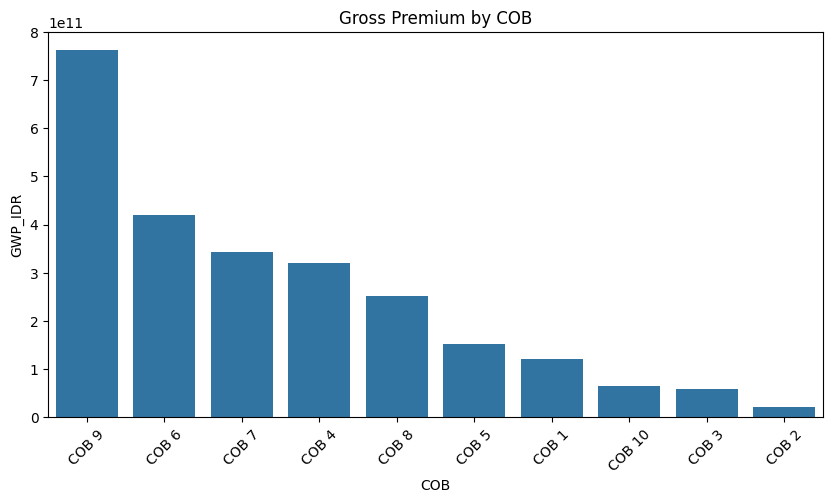


===== SUMMARY BY BRANCH_ =====
               GWP_IDR   NET_PREMIUM   SUM_INSURED  POLICY_NO
BRANCH_                                                      
BRANCH K  1.176841e+12  8.415608e+11  1.031903e+15      46405
BRANCH J  4.146388e+11  3.198664e+11  1.447252e+15      45817
BRANCH D  1.592619e+11  1.098779e+11  9.646030e+13      12709
BRANCH E  1.542209e+11  1.367521e+11  1.010242e+14      10557
BRANCH A  1.518248e+11  1.321832e+11  8.408534e+13      10566


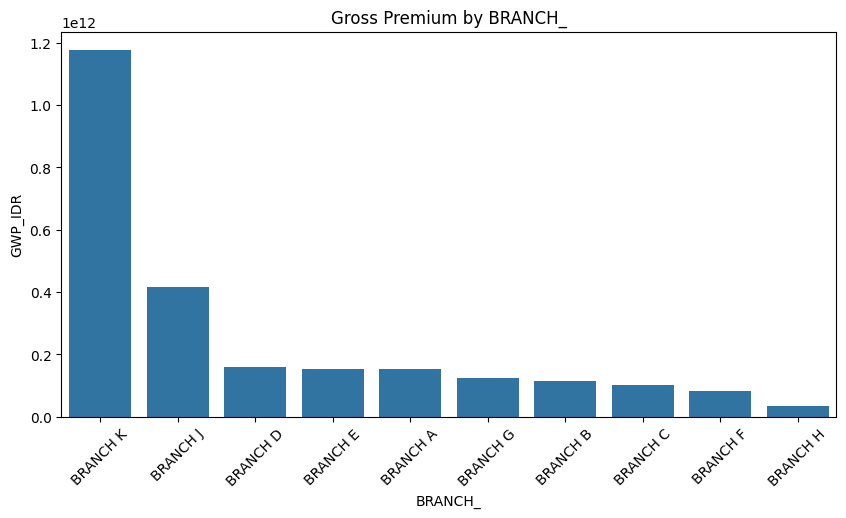


===== SUMMARY BY CHANNEL_ =====
                GWP_IDR   NET_PREMIUM   SUM_INSURED  POLICY_NO
CHANNEL_                                                      
CHANNEL D  7.576710e+11  7.121378e+11  4.202610e+14      61230
CHANNEL C  7.010222e+11  3.696118e+11  9.335389e+14       9303
CHANNEL B  4.881833e+11  4.836138e+11  1.253015e+14      37073
CHANNEL E  3.271361e+11  1.914889e+11  1.319732e+15       6453
CHANNEL A  2.367069e+11  2.072689e+11  1.877119e+14      42251


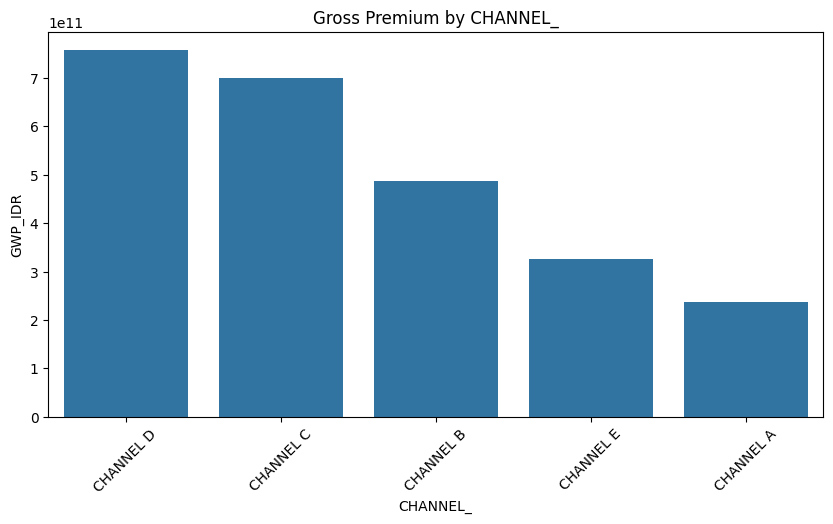

In [ ]:
# =========================
# STEP 2 - PORTFOLIO OVERVIEW
# =========================

# Net Premium
df_prem['NET_PREMIUM'] = (df_prem['GWP_IDR'] - df_prem['RWP_IDR'])

# Portfolio Summary
portfolio_summary = pd.DataFrame({
    'Metric': [
        'Total Gross Premium',
        'Total Net Premium',
        'Total Sum Insured',
        'Total Policies'],
    'Value': [
        df_prem['GWP_IDR'].sum(),
        df_prem['NET_PREMIUM'].sum(),
        df_prem['SUM_INSURED'].sum(),
        df_prem['POLICY_NO'].nunique()]})

print(portfolio_summary)

# =========================
# SEGMENT OVERVIEW
# =========================

segment_cols = ['COB', 'BRANCH_', 'CHANNEL_']

for seg in segment_cols:

    summary = (
        df_prem
        .groupby(seg)
        .agg({
            'GWP_IDR':'sum',
            'NET_PREMIUM':'sum',
            'SUM_INSURED':'sum',
            'POLICY_NO':'nunique' })
        .sort_values(by='GWP_IDR', ascending=False))

    print(f"\n===== SUMMARY BY {seg} =====")
    print(summary.head())

    # Visualization
    plt.figure(figsize=(10,5))

    sns.barplot(data=summary.reset_index(),
                x=seg,
                y='GWP_IDR')

    plt.title(f'Gross Premium by {seg}')
    plt.xticks(rotation=45)
    plt.show()

> Portofolio perusahaan menghasilkan gross premium sebesar Rp2,51 triliun dan net premium sebesar Rp1,96 triliun dari 156.301 polis, dengan total sum insured mencapai Rp2.986,5 triliun. Perbedaan antara gross dan net premium menunjukkan bahwa sebagian risiko telah dialihkan melalui skema reasuransi, namun mayoritas premi masih dipertahankan sebagai retensi perusahaan.

**Berdasarkan COB**
> Kontributor premi terbesar berasal dari COB 9 dengan gross premium sebesar Rp762,4 miliar atau sekitar 30% dari total portofolio, diikuti oleh COB 6 sebesar Rp420,7 miliar dan COB 7 sebesar Rp343,0 miliar. Menariknya, COB 6 memiliki nilai sum insured terbesar yaitu Rp1.354,8 triliun, jauh melampaui COB lainnya meskipun jumlah polisnya relatif kecil. Hal ini mengindikasikan bahwa COB 6 berisi risiko-risiko bernilai tinggi yang memerlukan perhatian khusus dari sisi underwriting dan manajemen risiko. Sementara itu, COB 9 dan COB 7 menunjukkan kombinasi volume polis dan kontribusi premi yang besar sehingga menjadi penggerak utama pendapatan perusahaan.

**Berdasarkan Branch**
> Dari sisi cabang, Branch K merupakan kontributor terbesar dengan gross premium sebesar Rp1,18 triliun atau hampir setengah dari total premi portofolio. Cabang ini juga memiliki jumlah polis tertinggi sehingga menjadi pusat bisnis utama perusahaan. Branch J menempati posisi kedua dengan gross premium sebesar Rp414,6 miliar, namun memiliki total sum insured tertinggi yaitu Rp1.447,3 triliun. Temuan ini menunjukkan bahwa Branch J menangani eksposur risiko yang lebih besar dibandingkan kontribusi preminya, sehingga perlu dilakukan evaluasi lebih lanjut terkait kecukupan premi terhadap risiko yang ditanggung.

**Berdasarkan Channel**
> Dari sisi distribusi, Channel D menjadi kontributor premi terbesar dengan gross premium sebesar Rp757,7 miliar dan lebih dari 61 ribu polis, menunjukkan efektivitas channel ini dalam menghasilkan volume bisnis. Namun dari sisi eksposur risiko, Channel E memiliki total sum insured terbesar yaitu Rp1.319,7 triliun meskipun hanya berasal dari sekitar 6.400 polis. Hal ini mengindikasikan bahwa Channel E berfokus pada bisnis dengan nilai pertanggungan yang sangat besar. Sementara itu, Channel C juga menunjukkan eksposur yang tinggi dengan sum insured mencapai Rp933,5 triliun, tetapi net premium yang diterima relatif lebih rendah dibanding gross premium, yang mengindikasikan penggunaan reasuransi yang lebih intensif pada channel tersebut.


> Secara keseluruhan, portofolio menunjukkan bahwa sumber pendapatan utama perusahaan terkonsentrasi pada COB 9, Branch K, dan Channel D, sementara eksposur risiko terbesar terkonsentrasi pada COB 6, Branch J, dan Channel E. Temuan ini mengindikasikan bahwa area dengan kontribusi premi terbesar tidak selalu merupakan area dengan eksposur risiko terbesar. Oleh karena itu, evaluasi profitabilitas, loss ratio, dan efektivitas reasuransi pada segmen-segmen tersebut menjadi prioritas untuk memastikan pertumbuhan premi tetap sejalan dengan tingkat risiko yang ditanggung perusahaan.

Analisis COB

In [ ]:
cob_analysis = df_prem.groupby('COB').agg(
    Total_GWP=('GWP_IDR', 'sum'),
    Total_RWP=('RWP_IDR', 'sum'),
    Total_GWC=('GWC_IDR', 'sum'),
    Total_Sum_Insured=('SUM_INSURED', 'sum'),
    Num_Policies=('POLICY_NO', 'nunique')
).reset_index()

cob_analysis['Prop_GWP'] = (cob_analysis['Total_GWP'] / total_gwp) * 100
cob_analysis['Prop_RWP'] = (cob_analysis['Total_RWP'] / total_rwp) * 100
cob_analysis['Prop_GWC'] = (cob_analysis['Total_GWC'] / total_gwc) * 100
cob_analysis['Prop_Sum_Insured'] = (cob_analysis['Total_Sum_Insured'] / total_sum_insured) * 100
cob_analysis['Prop_Num_Policies'] = (cob_analysis['Num_Policies'] / total_unique_policies) * 100

display(cob_analysis.sort_values(by='Total_GWP', ascending=False))

,COB,Total_GWP,Total_RWP,Total_GWC,Total_Sum_Insured,Num_Policies,Prop_GWP,Prop_RWP,Prop_GWC,Prop_Sum_Insured,Prop_Num_Policies
9,COB 9,7.624109e+11,2.954189e+11,7.531973e+10,7.365629e+14,46754,30.366231,54.046804,13.454797,24.662704,29.912796
6,COB 6,4.206605e+11,5.476914e+09,1.828905e+11,1.354778e+15,4876,16.754581,1.002000,32.670777,45.362712,3.119622
7,COB 7,3.429804e+11,2.834829e+08,5.677692e+10,2.128440e+13,41763,13.660641,0.051863,10.142389,0.712676,26.719599
4,COB 4,3.192075e+11,5.620782e+10,8.315382e+10,5.559157e+14,1693,12.713788,10.283206,14.854247,18.614003,1.083166
8,COB 8,2.515343e+11,4.482585e+07,1.093846e+11,7.185581e+13,2382,10.018415,0.008201,19.539996,2.405984,1.523983
5,COB 5,1.510009e+11,7.631139e+10,1.677699e+10,2.516984e+13,909,6.014248,13.961149,2.996970,0.842775,0.581570
0,COB 1,1.196189e+11,6.993509e+10,1.775699e+10,9.131532e+13,4983,4.764328,12.794606,3.172034,3.057557,3.188079
1,COB 10,6.489250e+10,0.000000e+00,1.048032e+10,1.055785e+14,52085,2.584618,0.000000,1.872159,3.535136,33.323523
3,COB 3,5.746793e+10,4.291977e+10,2.909283e+09,2.327878e+13,835,2.288903,7.852161,0.519702,0.779455,0.534226
2,COB 2,2.094564e+10,5.180234e+04,4.349233e+09,8.063062e+11,21,0.834248,0.000009,0.776929,0.026998,0.013436


> Analisis berdasarkan COB menunjukkan karakteristik portofolio yang berbeda pada setiap segmen. COB 9 menjadi kontributor premi terbesar dengan porsi 30,4% dari total GWP, sehingga merupakan penggerak utama pendapatan perusahaan. Sementara itu, COB 6 memiliki eksposur risiko terbesar dengan kontribusi 45,4% dari total sum insured meskipun hanya menyumbang 16,8% premi, sehingga perlu menjadi fokus dalam pengelolaan risiko. Di sisi lain, COB 10 memiliki jumlah polis terbesar (33,3% dari total polis), namun hanya menghasilkan 2,6% premi, yang mengindikasikan dominasi polis bernilai kecil. Temuan ini menunjukkan bahwa segmen penyumbang premi terbesar, eksposur terbesar, dan volume bisnis terbesar berasal dari COB yang berbeda sehingga memerlukan strategi pengelolaan yang berbeda pula.

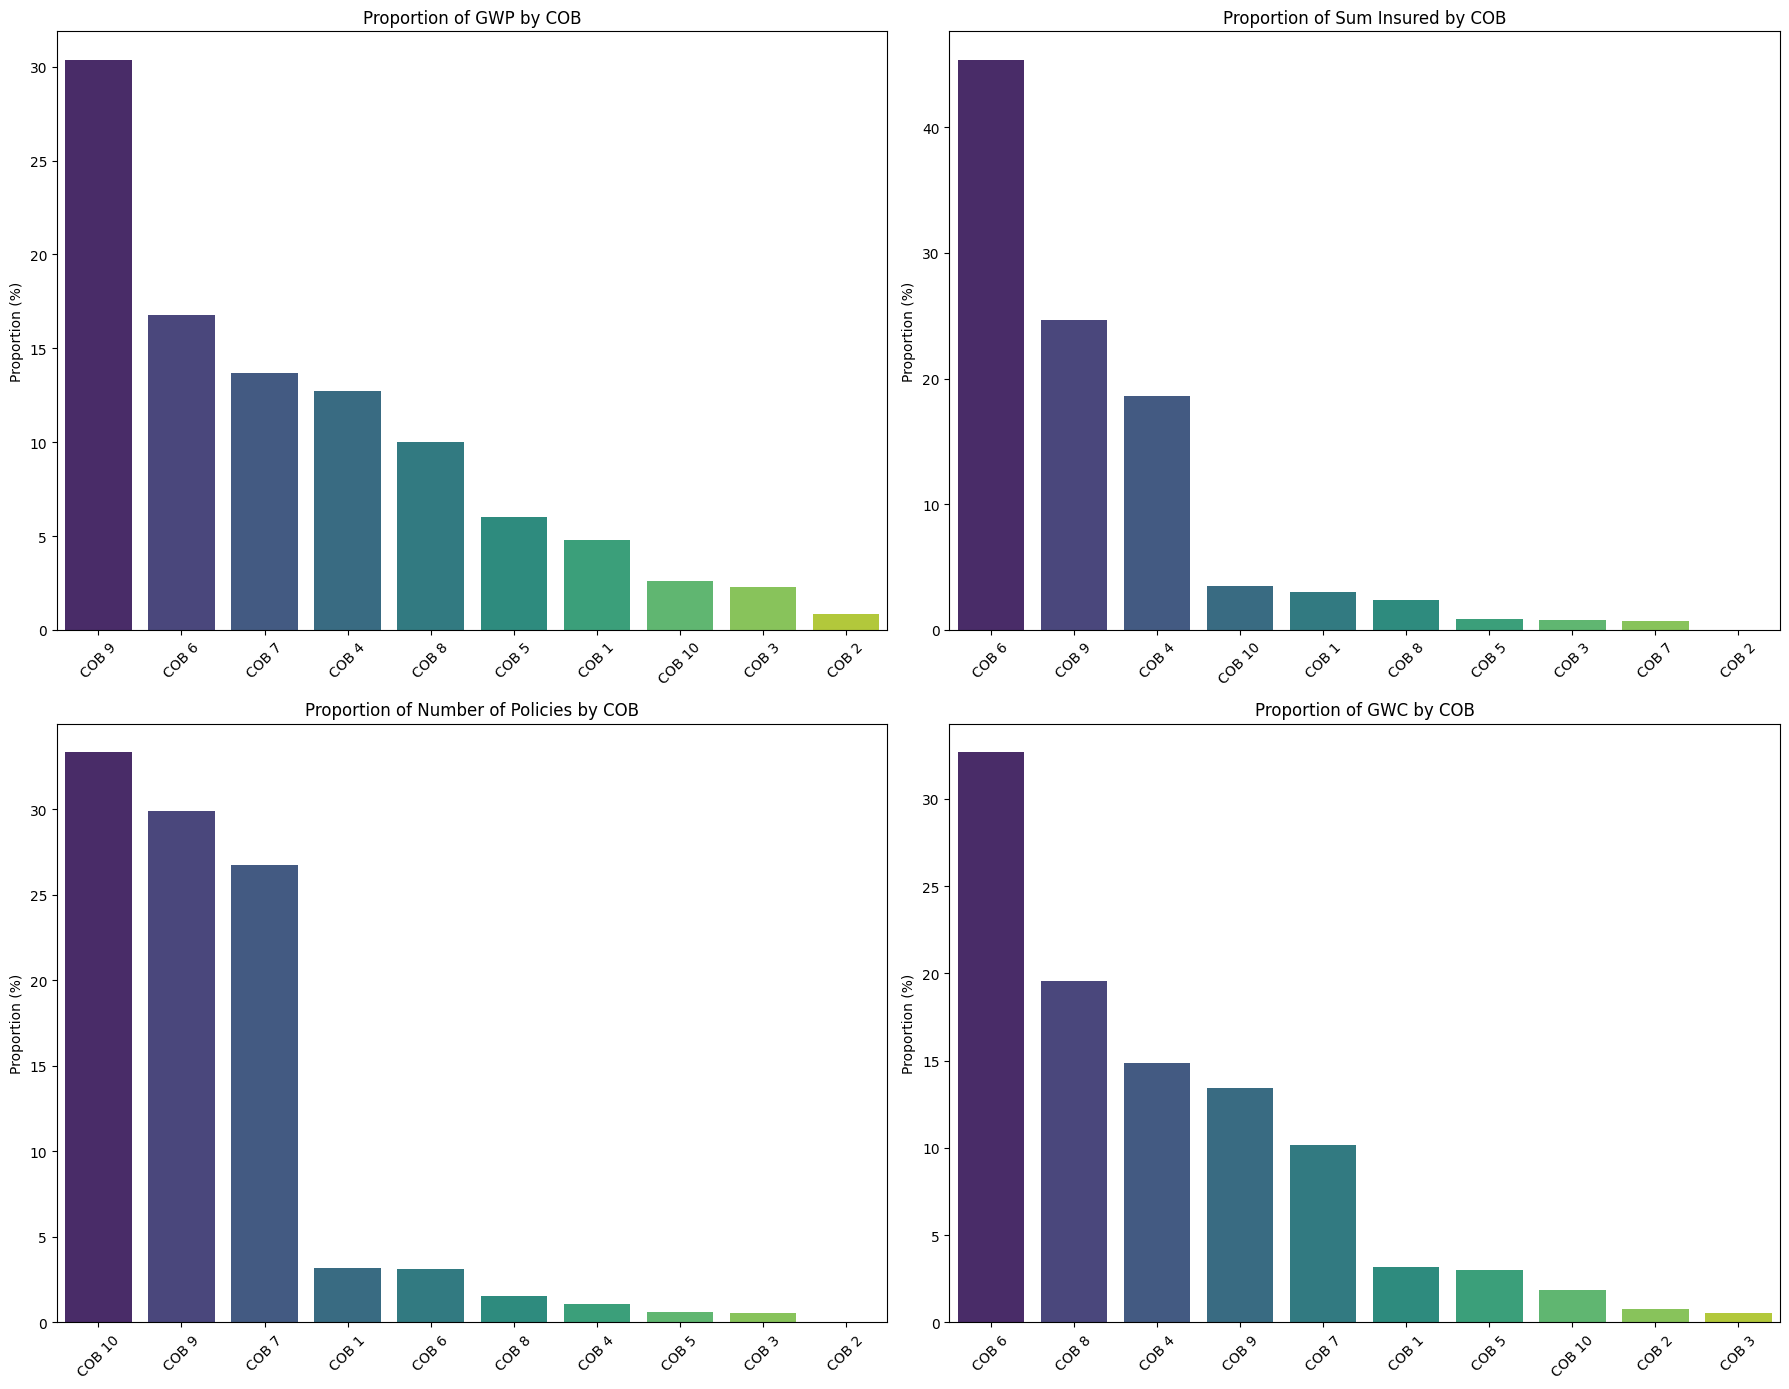

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics = ['Prop_GWP', 'Prop_Sum_Insured', 'Prop_Num_Policies', 'Prop_GWC']
titles = ['Proportion of GWP by COB', 'Proportion of Sum Insured by COB', 'Proportion of Number of Policies by COB', 'Proportion of GWC by COB']

for i, metric in enumerate(metrics):
    sns.barplot(x='COB', y=metric, data=cob_analysis.sort_values(by=metric, ascending=False), ax=axes[i], palette='viridis', hue='COB', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Analisis Branch

In [ ]:
branch_analysis = df_prem.groupby('BRANCH_').agg(
    Total_GWP=('GWP_IDR', 'sum'),
    Total_RWP=('RWP_IDR', 'sum'),
    Total_GWC=('GWC_IDR', 'sum'),
    Total_Sum_Insured=('SUM_INSURED', 'sum'),
    Num_Policies=('POLICY_NO', 'nunique')
).reset_index()

branch_analysis['Prop_GWP'] = (branch_analysis['Total_GWP'] / total_gwp) * 100
branch_analysis['Prop_RWP'] = (branch_analysis['Total_RWP'] / total_rwp) * 100
branch_analysis['Prop_GWC'] = (branch_analysis['Total_GWC'] / total_gwc) * 100
branch_analysis['Prop_Sum_Insured'] = (branch_analysis['Total_Sum_Insured'] / total_sum_insured) * 100
branch_analysis['Prop_Num_Policies'] = (branch_analysis['Num_Policies'] / total_unique_policies) * 100

display(branch_analysis.sort_values(by='Total_GWP', ascending=False))

,BRANCH_,Total_GWP,Total_RWP,Total_GWC,Total_Sum_Insured,Num_Policies,Prop_GWP,Prop_RWP,Prop_GWC,Prop_Sum_Insured,Prop_Num_Policies
9,BRANCH K,1.176841e+12,3.352804e+11,2.842884e+11,1.031903e+15,46405,46.872667,61.339461,50.784071,34.551725,29.689509
8,BRANCH J,4.146388e+11,9.477244e+10,6.587894e+10,1.447252e+15,45817,16.514740,17.338594,11.768335,48.459080,29.313312
3,BRANCH D,1.592619e+11,4.938400e+10,3.534764e+10,9.646030e+13,12709,6.343278,9.034789,6.314353,3.229829,8.131106
4,BRANCH E,1.542209e+11,1.746879e+10,3.353278e+10,1.010242e+14,10557,6.142497,3.195911,5.990153,3.382643,6.754275
0,BRANCH A,1.518248e+11,1.964157e+10,3.132674e+10,8.408534e+13,10566,6.047062,3.593420,5.596075,2.815472,6.760034
6,BRANCH G,1.238995e+11,5.053118e+09,3.149790e+10,5.685779e+13,6212,4.934819,0.924467,5.626652,1.903798,3.974383
1,BRANCH B,1.135347e+11,3.523662e+09,3.245401e+10,5.013800e+13,7218,4.522000,0.644653,5.797447,1.678796,4.618013
2,BRANCH C,1.008948e+11,1.102134e+10,2.140243e+10,5.816792e+13,9626,4.018559,2.016352,3.823239,1.947666,6.158630
5,BRANCH F,8.281286e+10,6.796002e+09,1.868748e+10,3.463459e+13,5291,3.298372,1.243327,3.338252,1.159687,3.385135
7,BRANCH H,3.279013e+10,3.656890e+09,5.382024e+09,2.602192e+13,1912,1.306005,0.669027,0.961422,0.871305,1.223281


> Dari sisi cabang, Branch K merupakan kontributor utama portofolio dengan menyumbang 46,9% total premi perusahaan, 50,8% total komisi, dan 61,3% total premi reasuransi. Hal ini menunjukkan bahwa sebagian besar aktivitas bisnis dan transfer risiko perusahaan terkonsentrasi pada cabang tersebut. Sementara itu, Branch J memiliki karakteristik yang berbeda, yaitu menyumbang 48,5% total sum insured meskipun kontribusi preminya hanya 16,5%. Temuan ini mengindikasikan bahwa Branch J mengelola eksposur risiko yang sangat besar dibandingkan pendapatan premi yang dihasilkan. Secara keseluruhan, Branch K menjadi penggerak utama pendapatan perusahaan, sedangkan Branch J menjadi pusat eksposur risiko terbesar yang perlu mendapat perhatian khusus dalam pengelolaan risiko dan profitabilitas.


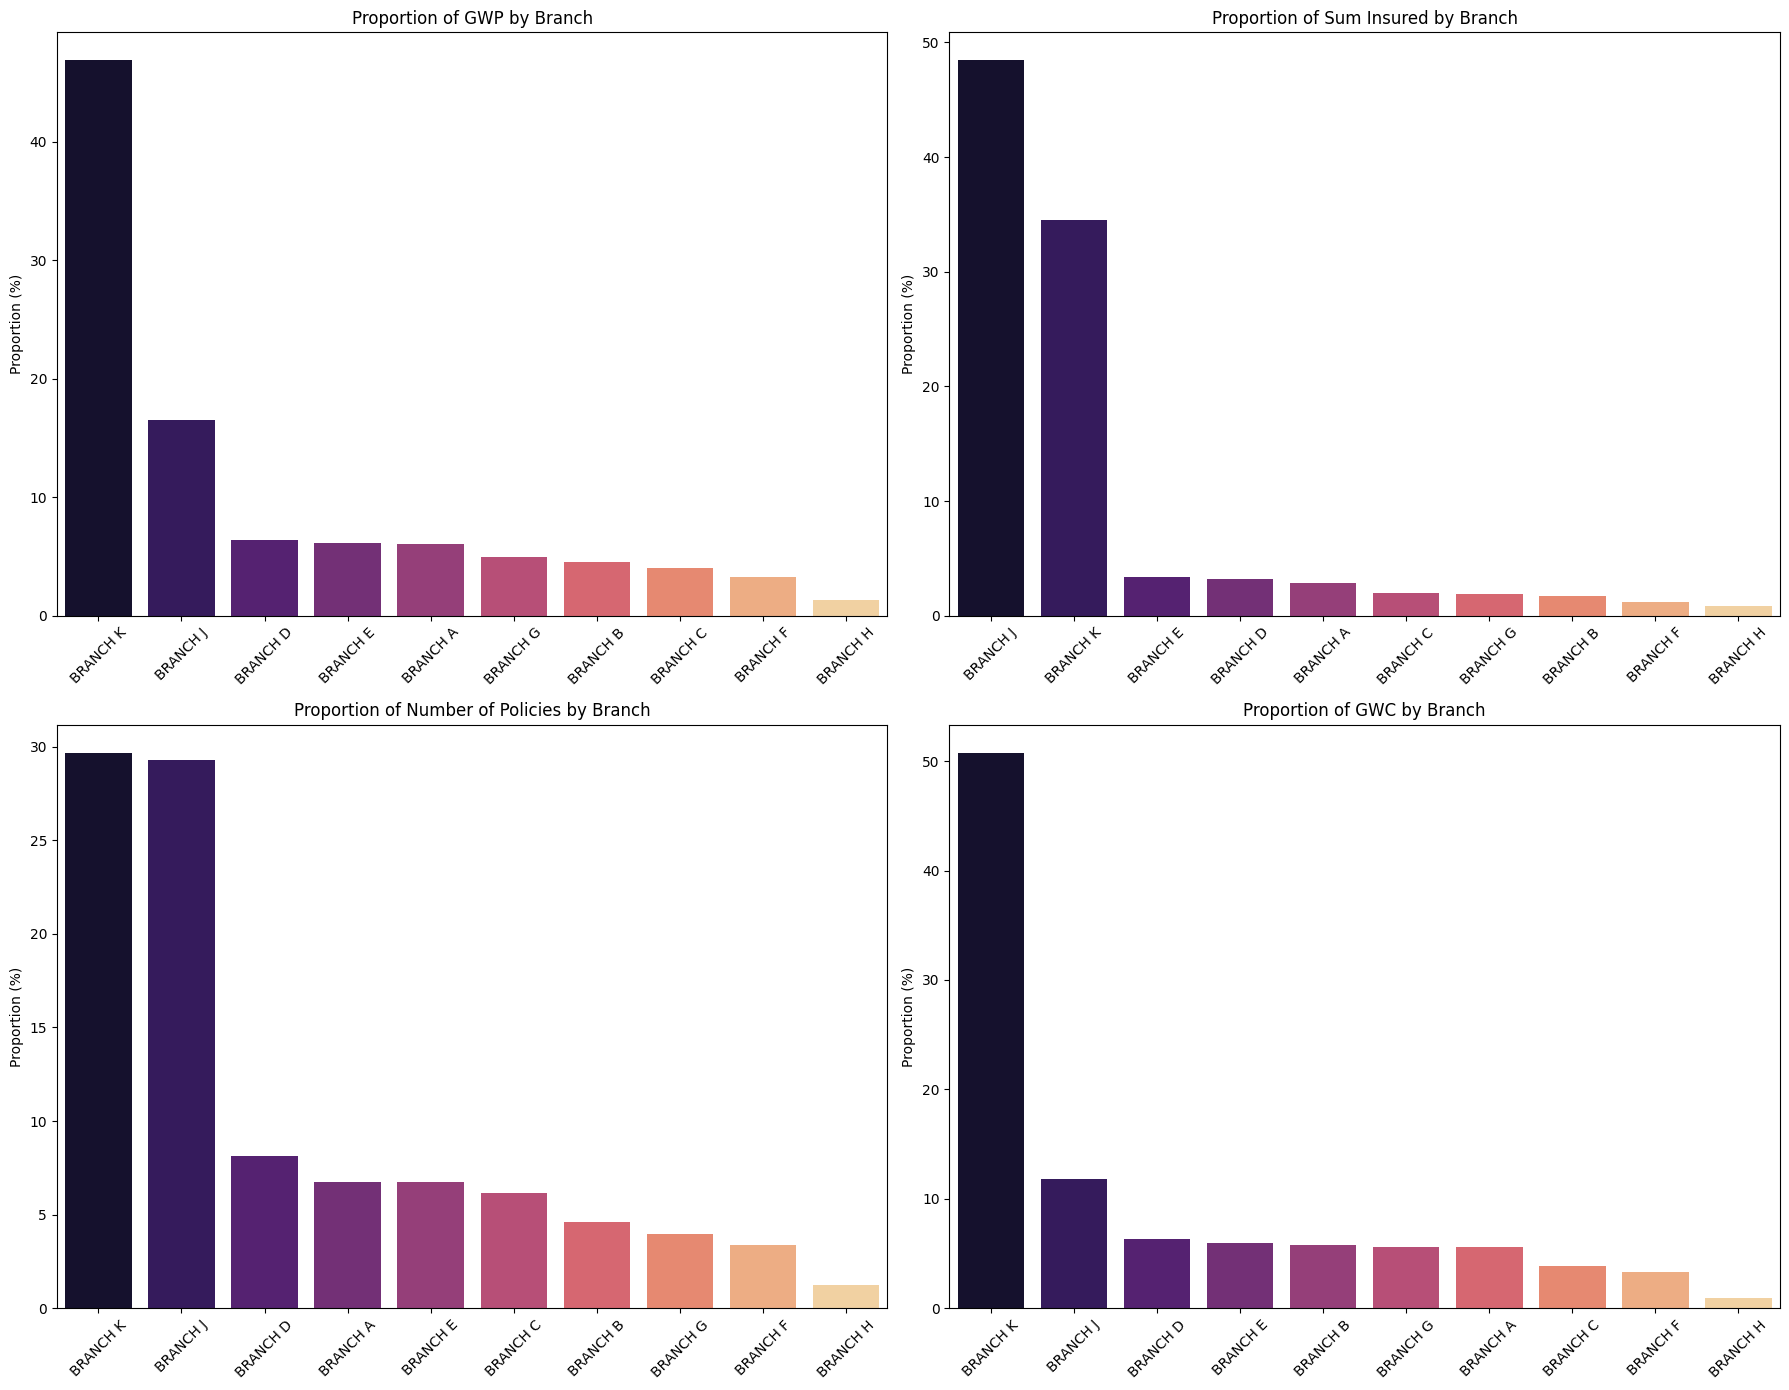

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics = ['Prop_GWP', 'Prop_Sum_Insured', 'Prop_Num_Policies', 'Prop_GWC']
titles = ['Proportion of GWP by Branch', 'Proportion of Sum Insured by Branch', 'Proportion of Number of Policies by Branch', 'Proportion of GWC by Branch']

for i, metric in enumerate(metrics):
    sns.barplot(x='BRANCH_', y=metric, data=branch_analysis.sort_values(by=metric, ascending=False), ax=axes[i], palette='magma', hue='BRANCH_', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Analisis Chanel

In [ ]:
channel_analysis = df_prem.groupby('CHANNEL_').agg(
    Total_GWP=('GWP_IDR', 'sum'),
    Total_RWP=('RWP_IDR', 'sum'),
    Total_GWC=('GWC_IDR', 'sum'),
    Total_Sum_Insured=('SUM_INSURED', 'sum'),
    Num_Policies=('POLICY_NO', 'nunique')
).reset_index()

channel_analysis['Prop_GWP'] = (channel_analysis['Total_GWP'] / total_gwp) * 100
channel_analysis['Prop_RWP'] = (channel_analysis['Total_RWP'] / total_rwp) * 100
channel_analysis['Prop_GWC'] = (channel_analysis['Total_GWC'] / total_gwc) * 100
channel_analysis['Prop_Sum_Insured'] = (channel_analysis['Total_Sum_Insured'] / total_sum_insured) * 100
channel_analysis['Prop_Num_Policies'] = (channel_analysis['Num_Policies'] / total_unique_policies) * 100

display(channel_analysis.sort_values(by='Total_GWP', ascending=False))

,CHANNEL_,Total_GWP,Total_RWP,Total_GWC,Total_Sum_Insured,Num_Policies,Prop_GWP,Prop_RWP,Prop_GWC,Prop_Sum_Insured,Prop_Num_Policies
3,CHANNEL D,7.576710e+11,4.553324e+10,1.889536e+11,4.202610e+14,61230,30.177446,8.330295,33.753862,14.071810,39.174413
2,CHANNEL C,7.010222e+11,3.314104e+11,1.016589e+11,9.335389e+14,9303,27.921168,60.631437,18.159912,31.258151,5.951977
1,CHANNEL B,4.881833e+11,4.569471e+09,1.867450e+11,1.253015e+14,37073,19.443961,0.835983,33.359336,4.195533,23.718978
4,CHANNEL E,3.271361e+11,1.356471e+11,3.030318e+10,1.319732e+15,6453,13.029575,24.816605,5.413231,44.189252,4.128572
0,CHANNEL A,2.367069e+11,2.943803e+10,5.213770e+10,1.877119e+14,42251,9.427851,5.385679,9.313658,6.285253,27.031817


> Dari sisi channel distribusi, Channel D merupakan kontributor premi terbesar dengan porsi 30,2% dari total GWP dan 39,2% dari total polis, sehingga menjadi sumber utama volume bisnis perusahaan. Sementara itu, Channel E memiliki eksposur risiko terbesar dengan kontribusi 44,2% terhadap total sum insured meskipun hanya menyumbang 13,0% premi dan 4,1% polis. Selain itu, Channel C mengalihkan sekitar 60,6% total premi reasuransi perusahaan, menunjukkan bahwa risiko yang berasal dari channel ini relatif lebih banyak ditransfer kepada reasuradur. Temuan ini menunjukkan bahwa Channel D berperan sebagai penggerak pendapatan, sedangkan Channel E dan Channel C menjadi channel yang perlu mendapat perhatian lebih dari sisi pengelolaan risiko.

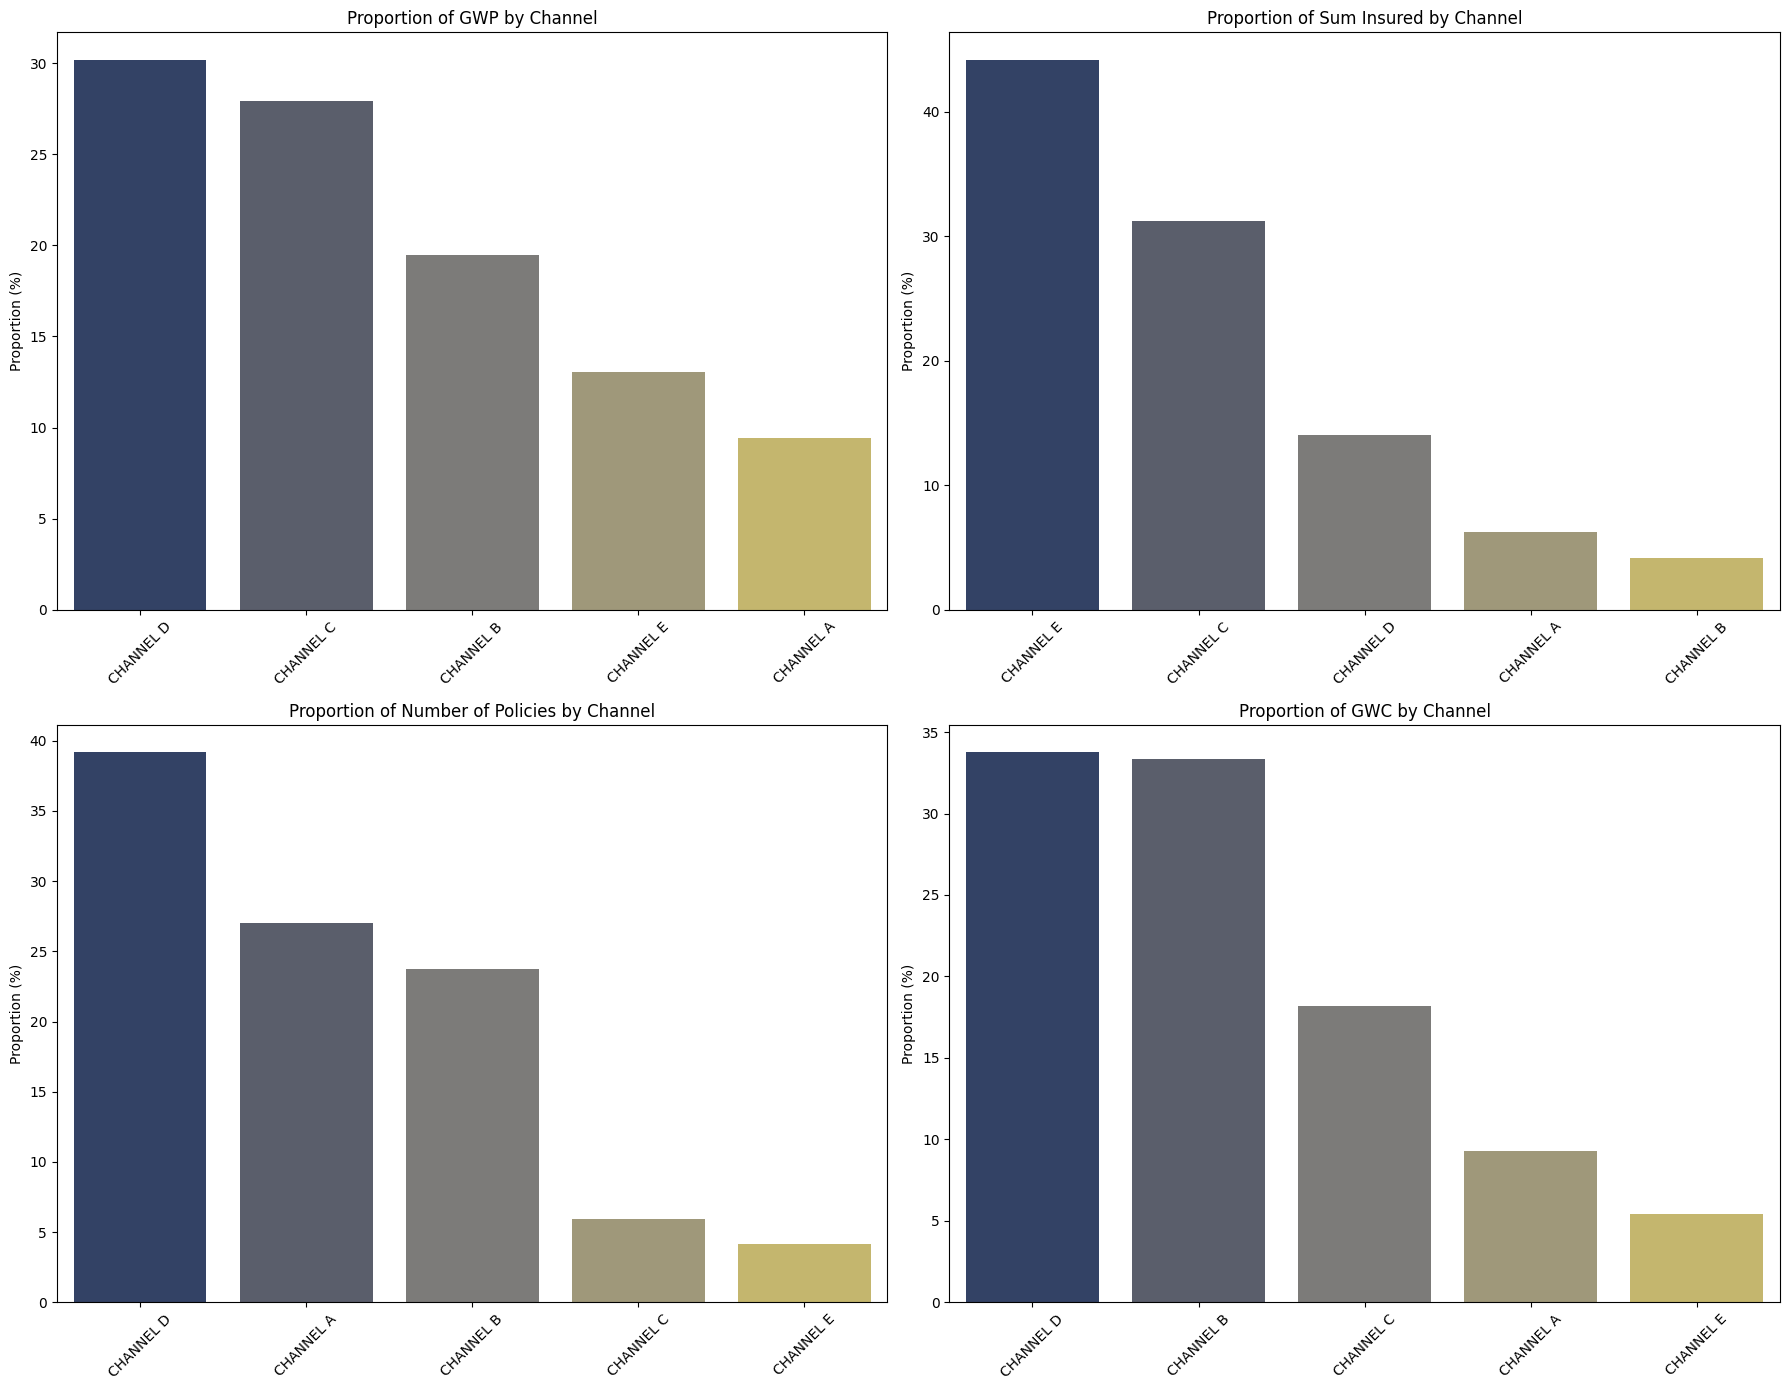

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

metrics = ['Prop_GWP', 'Prop_Sum_Insured', 'Prop_Num_Policies', 'Prop_GWC']
titles = ['Proportion of GWP by Channel', 'Proportion of Sum Insured by Channel', 'Proportion of Number of Policies by Channel', 'Proportion of GWC by Channel']

for i, metric in enumerate(metrics):
    sns.barplot(x='CHANNEL_', y=metric, data=channel_analysis.sort_values(by=metric, ascending=False), ax=axes[i], palette='cividis', hue='CHANNEL_', legend=False)
    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Claim Pattern Analysis

In [ ]:
# ============================================
# STEP 4 - CLAIM PATTERN ANALYSIS
# ============================================

# ── 4.0 Merge data segmen dari Raw Premium ──
# ——— 4.0 Merge data segmen dari Raw Premium ———
df_claim_merged = df_claim.copy()

# ── Hitung Gross & Net Incurred ──
df_claim_merged['GROSS_INCURRED'] = df_claim_merged['GRS_ST_IDR'] + df_claim_merged['GRS_OS_IDR']
df_claim_merged['NET_INCURRED'] = (df_claim_merged['GRS_ST_IDR'] + df_claim_merged['GRS_OS_IDR']) - \
                                   (df_claim_merged['RI_ST_IDR'] + df_claim_merged['RI_OS_IDR'])

# ── Tambah CLM_YEAR ──
df_claim_merged['CLM_YEAR'] = pd.to_datetime(df_claim_merged['DT_CLM']).dt.year

print("=== CLAIM OVERVIEW ===")
print(f"Total Gross Incurred : {df_claim_merged['GROSS_INCURRED'].sum():,.0f} IDR")
print(f"Total Net Incurred   : {df_claim_merged['NET_INCURRED'].sum():,.0f} IDR")
print(f"Total Claim Records  : {len(df_claim_merged):,}")
print(f"Total Unique Policies: {df_claim_merged['POLICY_NO'].nunique():,}")

=== CLAIM OVERVIEW ===
Total Gross Incurred : 1,238,881,565,028 IDR
Total Net Incurred   : 1,149,753,089,769 IDR
Total Claim Records  : 20,087
Total Unique Policies: 8,592


In [ ]:
# ── 4.1 Claim Frequency & Severity Overall ──
total_policies = df_prem['POLICY_NO'].nunique()
total_claims = df_claim_merged['CLM_REF'].nunique()

claim_frequency = total_claims / total_policies
claim_severity = df_claim_merged['GROSS_INCURRED'].sum() / total_claims

print("=== CLAIM FREQUENCY & SEVERITY (OVERALL) ===")
print(f"Total Policies    : {total_policies:,}")
print(f"Total Claims      : {total_claims:,}")
print(f"Claim Frequency   : {claim_frequency:.4f} (klaim per polis)")
print(f"Claim Severity    : {claim_severity:,.0f} IDR (rata-rata nilai klaim)")

=== CLAIM FREQUENCY & SEVERITY (OVERALL) ===
Total Policies    : 156,301
Total Claims      : 20,087
Claim Frequency   : 0.1285 (klaim per polis)
Claim Severity    : 61,675,789 IDR (rata-rata nilai klaim)


## Claim Analysis by COB

In [ ]:
# ── 4.2 Claim Analysis by COB ──
total_policies_per_cob = df_prem.groupby('COB')['POLICY_NO'].nunique().reset_index(name='Total_Policies_in_Prem')

cob_claim_analysis = df_claim_merged.groupby('COB').agg(
    Total_Gross_Incurred=('GROSS_INCURRED', 'sum'),
    Total_Net_Incurred=('NET_INCURRED', 'sum'),
    Num_Claims=('CLM_REF', 'count'),
    Num_Policies_with_Claims=('POLICY_NO', 'nunique')
).reset_index()

cob_claim_analysis = pd.merge(cob_claim_analysis, total_policies_per_cob, on='COB', how='left')
cob_claim_analysis['Claim_Frequency'] = cob_claim_analysis['Num_Claims'] / cob_claim_analysis['Total_Policies_in_Prem']
cob_claim_analysis['Claim_Severity'] = cob_claim_analysis['Total_Gross_Incurred'] / cob_claim_analysis['Num_Claims']
cob_claim_analysis['Prop_Gross'] = (cob_claim_analysis['Total_Gross_Incurred'] / cob_claim_analysis['Total_Gross_Incurred'].sum()) * 100

print("\n=== CLAIM ANALYSIS BY COB ===")
display(cob_claim_analysis.sort_values('Total_Gross_Incurred', ascending=False))


=== CLAIM ANALYSIS BY COB ===


,COB,Total_Gross_Incurred,Total_Net_Incurred,Num_Claims,Num_Policies_with_Claims,Total_Policies_in_Prem,Claim_Frequency,Claim_Severity,Prop_Gross
6,COB 6,3.840697e+11,3.836386e+11,1476,109,4876,0.302707,2.602098e+08,31.001324
7,COB 7,2.981591e+11,2.981295e+11,13243,6986,41763,0.317099,2.251447e+07,24.066800
4,COB 4,2.913542e+11,2.802180e+11,1289,208,1693,0.761370,2.260312e+08,23.517517
9,COB 9,1.306912e+11,8.792284e+10,2826,704,46754,0.060444,4.624600e+07,10.549127
5,COB 5,5.802572e+10,3.704782e+10,80,62,909,0.088009,7.253215e+08,4.683718
8,COB 8,3.782976e+10,3.782976e+10,318,57,2382,0.133501,1.189615e+08,3.053542
0,COB 1,2.616669e+10,1.278392e+10,271,97,4983,0.054385,9.655605e+07,2.112122
1,COB 10,5.870562e+09,5.870562e+09,373,330,52085,0.007161,1.573877e+07,0.473860
2,COB 2,5.434200e+09,5.434200e+09,28,3,21,1.333333,1.940786e+08,0.438638
3,COB 3,1.280414e+09,8.779565e+08,183,36,835,0.219162,6.996799e+06,0.103352


## Claim Analysis by Branch

In [ ]:
# ── 4.3 Claim Analysis by Branch ──
total_policies_per_branch = df_prem.groupby('BRANCH_')['POLICY_NO'].nunique().reset_index(name='Total_Policies_in_Prem')

branch_claim_analysis = df_claim_merged.groupby('BRANCH_').agg(
    Total_Gross_Incurred=('GROSS_INCURRED', 'sum'),
    Total_Net_Incurred=('NET_INCURRED', 'sum'),
    Num_Claims=('CLM_REF', 'count'),
    Num_Policies_with_Claims=('POLICY_NO', 'nunique')
).reset_index()

branch_claim_analysis = pd.merge(branch_claim_analysis, total_policies_per_branch, on='BRANCH_', how='left')
branch_claim_analysis['Claim_Frequency'] = branch_claim_analysis['Num_Claims'] / branch_claim_analysis['Total_Policies_in_Prem']
branch_claim_analysis['Claim_Severity'] = branch_claim_analysis['Total_Gross_Incurred'] / branch_claim_analysis['Num_Claims']
branch_claim_analysis['Prop_Gross'] = (branch_claim_analysis['Total_Gross_Incurred'] / branch_claim_analysis['Total_Gross_Incurred'].sum()) * 100

print("\n=== CLAIM ANALYSIS BY BRANCH ===")
display(branch_claim_analysis.sort_values('Total_Gross_Incurred', ascending=False))


=== CLAIM ANALYSIS BY BRANCH ===


,BRANCH_,Total_Gross_Incurred,Total_Net_Incurred,Num_Claims,Num_Policies_with_Claims,Total_Policies_in_Prem,Claim_Frequency,Claim_Severity,Prop_Gross
9,BRANCH K,9.368591e+11,8.734054e+11,7336,1614,46405,0.158086,1.277071e+08,75.621362
8,BRANCH J,1.066501e+11,1.003516e+11,4732,2889,45817,0.103280,2.253806e+07,8.608579
4,BRANCH E,3.978000e+10,3.445506e+10,2245,649,10557,0.212655,1.771938e+07,3.210961
6,BRANCH G,2.913392e+10,2.614521e+10,1281,487,6212,0.206214,2.274311e+07,2.351631
1,BRANCH B,2.826113e+10,2.819578e+10,676,488,7218,0.093655,4.180640e+07,2.281181
0,BRANCH A,2.738520e+10,2.466859e+10,1403,790,10566,0.132784,1.951903e+07,2.210478
2,BRANCH C,2.696637e+10,2.630699e+10,757,522,9626,0.078641,3.562268e+07,2.176670
5,BRANCH F,2.020514e+10,1.819088e+10,375,279,5291,0.070875,5.388036e+07,1.630918
3,BRANCH D,1.981930e+10,1.453108e+10,1157,791,12709,0.091038,1.712990e+07,1.599774
7,BRANCH H,3.821293e+09,3.502531e+09,125,83,1912,0.065377,3.057034e+07,0.308447


## Claim Analysis by Channel

In [ ]:
# ── 4.4 Claim Analysis by Channel ──
total_policies_per_channel = df_prem.groupby('CHANNEL_')['POLICY_NO'].nunique().reset_index(name='Total_Policies_in_Prem')

channel_claim_analysis = df_claim_merged.groupby('CHANNEL_').agg(
    Total_Gross_Incurred=('GROSS_INCURRED', 'sum'),
    Total_Net_Incurred=('NET_INCURRED', 'sum'),
    Num_Claims=('CLM_REF', 'count'),
    Num_Policies_with_Claims=('POLICY_NO', 'nunique')
).reset_index()

channel_claim_analysis = pd.merge(channel_claim_analysis, total_policies_per_channel, on='CHANNEL_', how='left')
channel_claim_analysis['Claim_Frequency'] = channel_claim_analysis['Num_Claims'] / channel_claim_analysis['Total_Policies_in_Prem']
channel_claim_analysis['Claim_Severity'] = channel_claim_analysis['Total_Gross_Incurred'] / channel_claim_analysis['Num_Claims']
channel_claim_analysis['Prop_Gross'] = (channel_claim_analysis['Total_Gross_Incurred'] / channel_claim_analysis['Total_Gross_Incurred'].sum()) * 100

print("\n=== CLAIM ANALYSIS BY CHANNEL ===")
display(channel_claim_analysis.sort_values('Total_Gross_Incurred', ascending=False))


=== CLAIM ANALYSIS BY CHANNEL ===


,CHANNEL_,Total_Gross_Incurred,Total_Net_Incurred,Num_Claims,Num_Policies_with_Claims,Total_Policies_in_Prem,Claim_Frequency,Claim_Severity,Prop_Gross
1,CHANNEL B,5.619972e+11,5.618132e+11,2609,586,37073,0.070375,2.154071e+08,45.363272
2,CHANNEL C,3.819460e+11,3.169728e+11,4752,1034,9303,0.510803,8.037584e+07,30.829902
3,CHANNEL D,1.307351e+11,1.253522e+11,5998,4308,61230,0.097959,2.179645e+07,10.552673
4,CHANNEL E,8.929555e+10,7.577351e+10,4455,856,6453,0.690377,2.004389e+07,7.207755
0,CHANNEL A,7.490772e+10,6.984139e+10,2273,1808,42251,0.053798,3.295544e+07,6.046398


## Visualisasi Distribusi

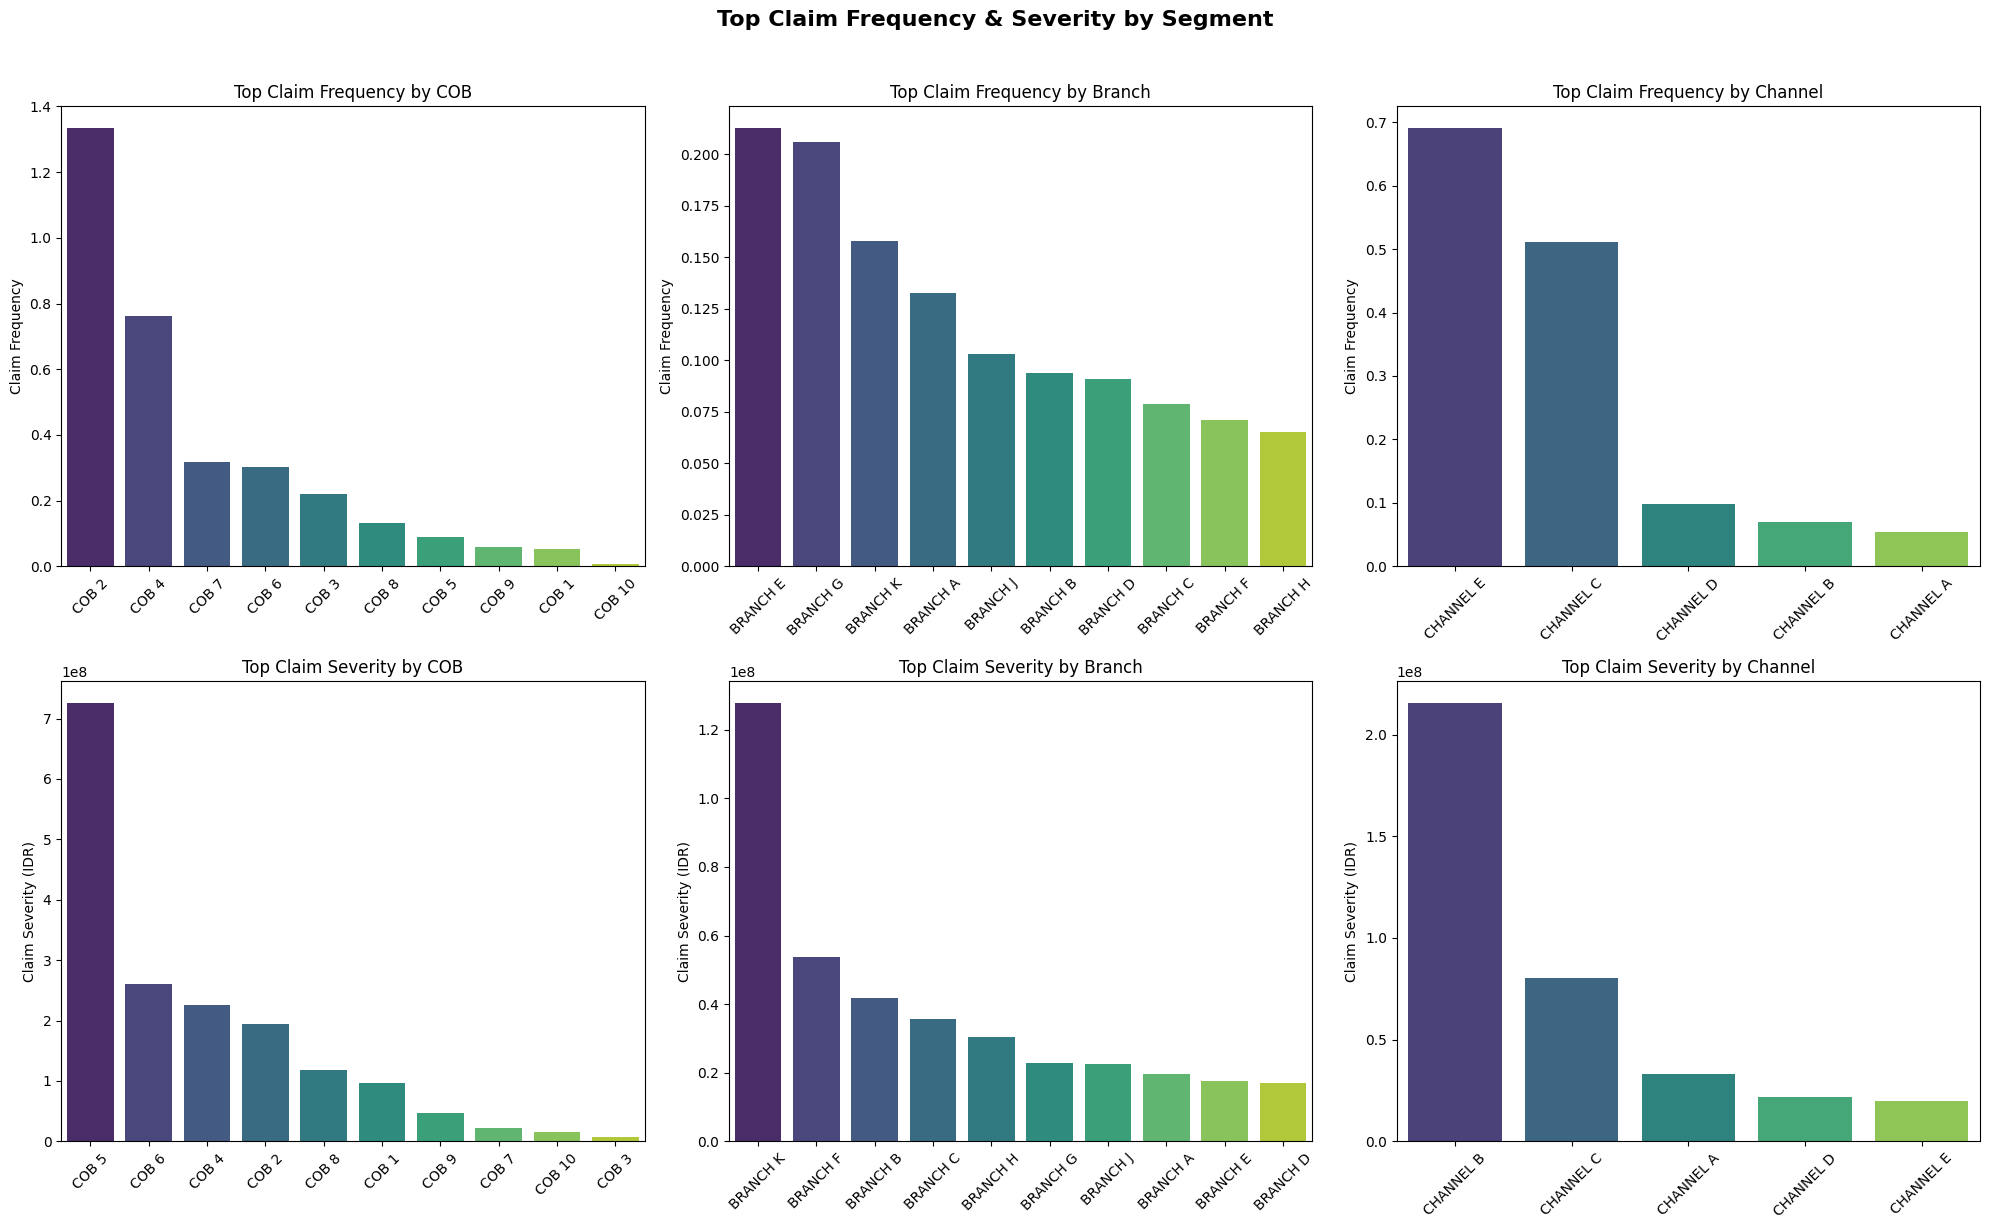

In [ ]:
# ── Top Claim Frequency & Severity per Segmen ──

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

viridis = plt.cm.viridis

segments = [
    (cob_claim_analysis, 'COB', 'COB'),
    (branch_claim_analysis, 'BRANCH_', 'Branch'),
    (channel_claim_analysis, 'CHANNEL_', 'Channel')
]

for i, (data, col, label) in enumerate(segments):
    # ── Top Claim Frequency ──
    sns.barplot(
        x=col, y='Claim_Frequency',
        data=data.sort_values('Claim_Frequency', ascending=False),
        ax=axes[0][i], palette='viridis',
        hue=col, legend=False
    )
    axes[0][i].set_title(f'Top Claim Frequency by {label}')
    axes[0][i].set_ylabel('Claim Frequency')
    axes[0][i].set_xlabel('')
    axes[0][i].tick_params(axis='x', rotation=45)

    # ── Top Claim Severity ──
    sns.barplot(
        x=col, y='Claim_Severity',
        data=data.sort_values('Claim_Severity', ascending=False),
        ax=axes[1][i], palette='viridis',
        hue=col, legend=False
    )
    axes[1][i].set_title(f'Top Claim Severity by {label}')
    axes[1][i].set_ylabel('Claim Severity (IDR)')
    axes[1][i].set_xlabel('')
    axes[1][i].tick_params(axis='x', rotation=45)

plt.suptitle('Top Claim Frequency & Severity by Segment',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

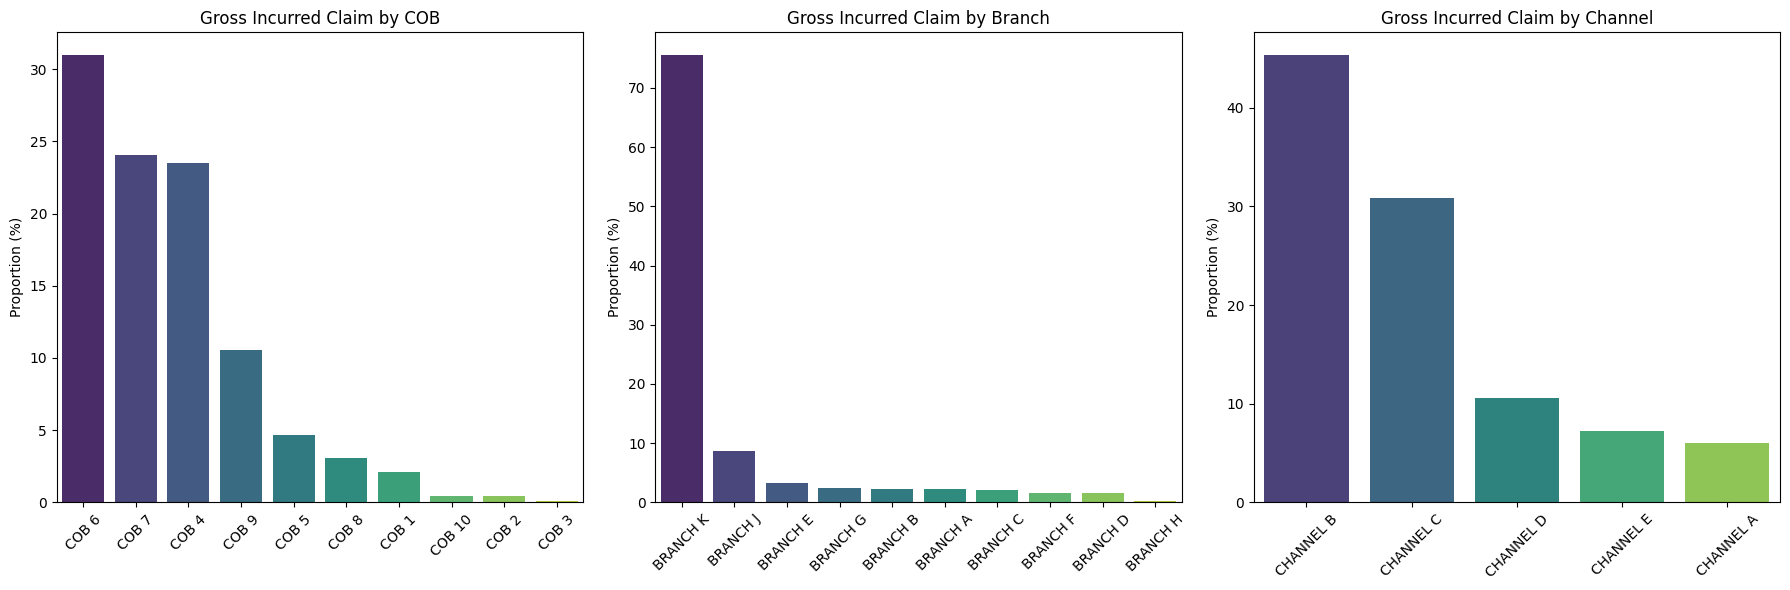

In [ ]:
# ── 4.5 Visualisasi Distribusi Claim per Segmen ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = [
    (cob_claim_analysis, 'COB', 'COB'),
    (branch_claim_analysis, 'BRANCH_', 'Branch'),
    (channel_claim_analysis, 'CHANNEL_', 'Channel')
]

for i, (data, col, label) in enumerate(datasets):
    sns.barplot(
        x=col, y='Prop_Gross',
        data=data.sort_values('Prop_Gross', ascending=False),
        ax=axes[i], palette='viridis',
        hue=col, legend=False
    )
    axes[i].set_title(f'Gross Incurred Claim by {label}')
    axes[i].set_ylabel('Proportion (%)')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Trend Analysis


=== YEARLY TREND ===


,CLM_YEAR,Total_Gross,Total_Net,Claim_Count
0,2021,5.909887e+11,5.609290e+11,3560
1,2022,3.167121e+11,2.932850e+11,6381
2,2023,2.162093e+11,1.995775e+11,6243
3,2024,1.056164e+11,8.746893e+10,3540
4,2025,9.209372e+09,8.347047e+09,219
5,2026,1.457094e+08,1.457094e+08,144


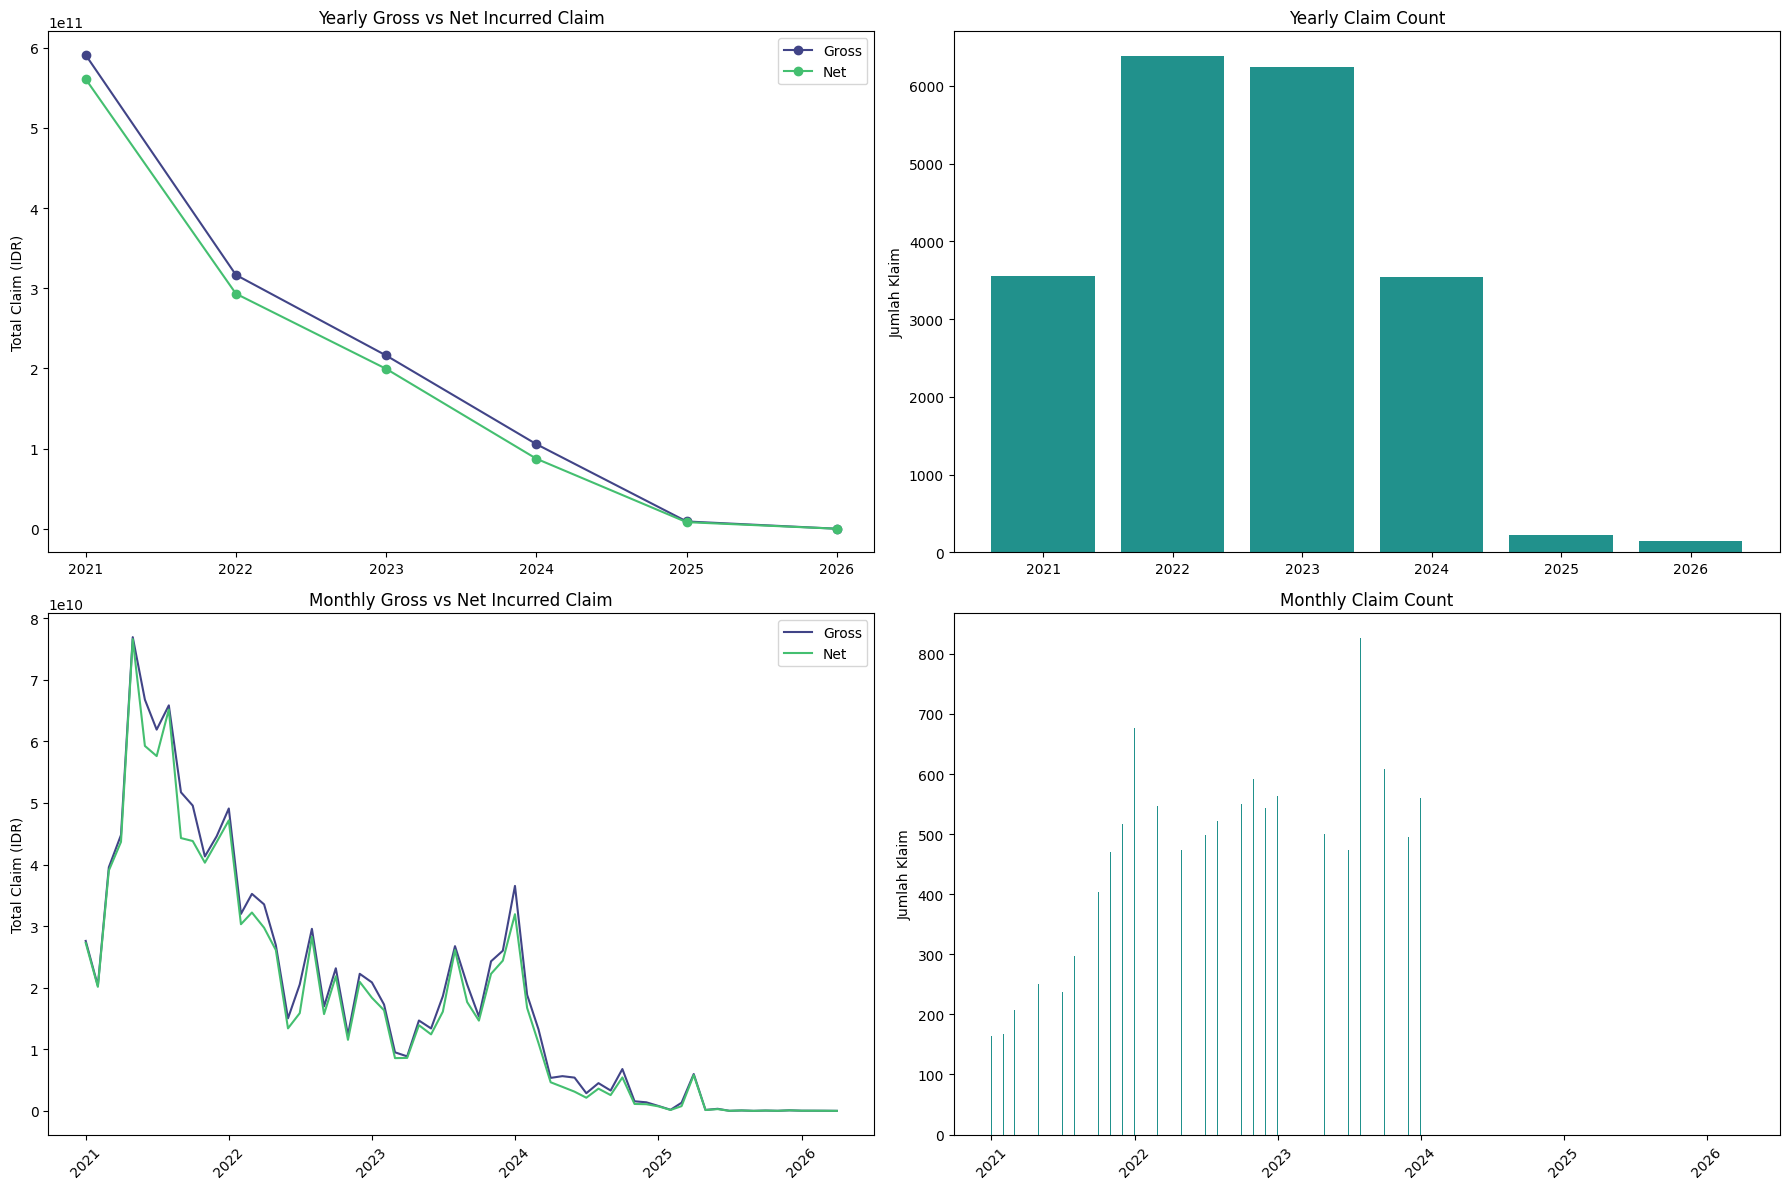

In [ ]:
# ── 4.6 Trend Analysis ──

viridis = plt.cm.viridis

# Yearly trend
yearly_trend = df_claim_merged.groupby('CLM_YEAR').agg(
    Total_Gross=('GROSS_INCURRED', 'sum'),
    Total_Net=('NET_INCURRED', 'sum'),
    Claim_Count=('CLM_REF', 'nunique')
).reset_index()

print("\n=== YEARLY TREND ===")
display(yearly_trend)

# Monthly trend
df_claim_merged['Month_Year'] = df_claim_merged['DT_CLM'].dt.to_period('M')
monthly_trend = df_claim_merged.groupby('Month_Year').agg(
    Total_Gross=('GROSS_INCURRED', 'sum'),
    Total_Net=('NET_INCURRED', 'sum'),
    Claim_Count=('CLM_REF', 'nunique')
).reset_index()
monthly_trend['Month_Year'] = monthly_trend['Month_Year'].dt.to_timestamp()

# Plot
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Yearly - nilai klaim
axes[0][0].plot(yearly_trend['CLM_YEAR'], yearly_trend['Total_Gross'],
                marker='o', label='Gross', color=viridis(0.2))
axes[0][0].plot(yearly_trend['CLM_YEAR'], yearly_trend['Total_Net'],
                marker='o', label='Net', color=viridis(0.7))
axes[0][0].set_title('Yearly Gross vs Net Incurred Claim')
axes[0][0].set_ylabel('Total Claim (IDR)')
axes[0][0].legend()

# Yearly - jumlah klaim
axes[0][1].bar(yearly_trend['CLM_YEAR'], yearly_trend['Claim_Count'],
               color=viridis(0.5))
axes[0][1].set_title('Yearly Claim Count')
axes[0][1].set_ylabel('Jumlah Klaim')

# Monthly - nilai klaim
axes[1][0].plot(monthly_trend['Month_Year'], monthly_trend['Total_Gross'],
                color=viridis(0.2), label='Gross')
axes[1][0].plot(monthly_trend['Month_Year'], monthly_trend['Total_Net'],
                color=viridis(0.7), label='Net')
axes[1][0].set_title('Monthly Gross vs Net Incurred Claim')
axes[1][0].set_ylabel('Total Claim (IDR)')
axes[1][0].tick_params(axis='x', rotation=45)
axes[1][0].legend()

# Monthly - jumlah klaim
axes[1][1].bar(monthly_trend['Month_Year'], monthly_trend['Claim_Count'],
               color=viridis(0.5))
axes[1][1].set_title('Monthly Claim Count')
axes[1][1].set_ylabel('Jumlah Klaim')
axes[1][1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- Terlihat bahwa Total Gross dan Total Net sama-sama turun drastis dari tahun ke tahun. Di 2021 Total Gross mencapai 5.9 × 10¹¹ dengan 3.560 klaim, lalu di 2022 naik jadi 6.381 klaim tapi nilai grossnya turun jadi 3.1 × 10¹¹. Ini konfirmasi dari analisis catastrophic tadi — 2021 klaimnya sedikit tapi nilainya jumbo, 2022-2023 klaimnya banyak tapi nilai per klaimnya lebih kecil. Data 2025-2026 kemungkinan belum lengkap karena jumlah klaimnya sangat sedikit.
- Nilai klaim turun terus dari 2021 ke 2026. Garis Gross dan Net sangat berdekatan di semua tahun — artinya reasuransi tidak terlalu banyak membantu mengurangi beban klaim. Gap antara Gross dan Net relatif kecil, yang mengindikasikan bahwa recovery dari reasuransi tidak signifikan.

- Nilai klaim bulanan sangat tinggi di awal 2021 lalu turun secara gradual. Ada lonjakan kecil di sekitar 2023 tapi tidak sebesar 2021. Garis Gross dan Net hampir selalu berdekatan — sekali lagi mengkonfirmasi bahwa reasuransi kurang efektif dalam menyerap beban klaim.

- Jumlah klaim per bulan sangat fluktuatif. Ada lonjakan signifikan di beberapa bulan tertentu terutama di 2022-2024 yang bisa mencapai 600-800 klaim per bulan. Ini berkaitan dengan catastrophic days yang sudah diidentifikasi sebelumnya.

## Large Claim Analysis

In [ ]:
# ── 4.7 Large Claim Analysis ──
LARGE_CLAIM_THRESHOLD = 1_000_000_000

df_claim_merged['IS_LARGE_CLAIM'] = df_claim_merged['GROSS_INCURRED'] > LARGE_CLAIM_THRESHOLD

large_claims = df_claim_merged[df_claim_merged['IS_LARGE_CLAIM'] == True]
normal_claims = df_claim_merged[df_claim_merged['IS_LARGE_CLAIM'] == False]

print("=== LARGE CLAIM ANALYSIS ===")
print(f"Jumlah Large Claim   : {len(large_claims):,}")
print(f"Jumlah Normal Claim  : {len(normal_claims):,}")
print(f"% Large Claim        : {len(large_claims)/len(df_claim_merged)*100:.2f}%")
print(f"Total Gross Large    : {large_claims['GROSS_INCURRED'].sum():,.0f} IDR")
print(f"Total Gross Normal   : {normal_claims['GROSS_INCURRED'].sum():,.0f} IDR")
print(f"% Nilai Large Claim  : {large_claims['GROSS_INCURRED'].sum()/df_claim_merged['GROSS_INCURRED'].sum()*100:.2f}%")

# Distribusi large claim per segmen
if not large_claims.empty:
    print("\n=== LARGE CLAIM per COB ===")
    display(large_claims.groupby('COB').agg(
        Jumlah=('CLM_REF', 'count'),
        Total_Gross=('GROSS_INCURRED', 'sum')
    ).sort_values('Total_Gross', ascending=False))

    print("\n=== LARGE CLAIM per BRANCH ===")
    display(large_claims.groupby('BRANCH_').agg(
        Jumlah=('CLM_REF', 'count'),
        Total_Gross=('GROSS_INCURRED', 'sum')
    ).sort_values('Total_Gross', ascending=False))

    print("\n=== LARGE CLAIM per CHANNEL ===")
    display(large_claims.groupby('CHANNEL_').agg(
        Jumlah=('CLM_REF', 'count'),
        Total_Gross=('GROSS_INCURRED', 'sum')
    ).sort_values('Total_Gross', ascending=False))
else:
    print("Tidak ada large claim di atas threshold!")

=== LARGE CLAIM ANALYSIS ===
Jumlah Large Claim   : 248
Jumlah Normal Claim  : 19,839
% Large Claim        : 1.23%
Total Gross Large    : 536,194,684,821 IDR
Total Gross Normal   : 702,686,880,208 IDR
% Nilai Large Claim  : 43.28%

=== LARGE CLAIM per COB ===


,Jumlah,Total_Gross
COB,,
COB 6,127,2.652114e+11
COB 4,57,1.130857e+11
COB 9,31,6.043607e+10
COB 5,18,4.712929e+10
COB 8,8,3.745963e+10
COB 1,7,1.287260e+10



=== LARGE CLAIM per BRANCH ===


,Jumlah,Total_Gross
BRANCH_,,
BRANCH K,197,4.045428e+11
BRANCH J,22,4.152058e+10
BRANCH B,5,2.213393e+10
BRANCH C,4,1.597437e+10
BRANCH G,6,1.533810e+10
BRANCH F,6,1.484151e+10
BRANCH A,3,1.275529e+10
BRANCH D,4,5.450958e+09
BRANCH E,1,3.637124e+09



=== LARGE CLAIM per CHANNEL ===


,Jumlah,Total_Gross
CHANNEL_,,
CHANNEL B,121,2.567440e+11
CHANNEL C,76,1.498969e+11
CHANNEL D,23,7.708616e+10
CHANNEL A,14,3.047533e+10
CHANNEL E,14,2.199225e+10


## Catastrophic Claim

In [ ]:
# ── 4.8 Catastrophic Claim Analysis ──

# Catastrophic = lonjakan klaim tidak wajar di tanggal/periode tertentu
# Caranya: hitung total klaim per hari, cari yang anomali

daily_claim_count = df_claim_merged.groupby('DT_CLM').agg(
    Daily_Claim_Count=('CLM_REF', 'count'),
    Daily_Gross=('GROSS_INCURRED', 'sum')
).reset_index()

# Hitung statistik dasar
mean_daily_count = daily_claim_count['Daily_Claim_Count'].mean()
std_daily_count = daily_claim_count['Daily_Claim_Count'].std()
cat_threshold_count = mean_daily_count + (2 * std_daily_count)

# Threshold 2 - dari nilai gross incurred per hari
mean_daily_gross = daily_claim_count['Daily_Gross'].mean()
std_daily_gross = daily_claim_count['Daily_Gross'].std()
cat_threshold_gross = mean_daily_gross + (2 * std_daily_gross)

print("=== CATASTROPHIC CLAIM DETECTION ===")
print(f"Threshold Count  : {cat_threshold_count:.2f} klaim/hari")
print(f"Threshold Gross  : {cat_threshold_gross:,.0f} IDR/hari")

# Catastrophic = anomali di salah satu atau keduanya
catastrophic_days = daily_claim_count[
    (daily_claim_count['Daily_Claim_Count'] > cat_threshold_count) |
    (daily_claim_count['Daily_Gross'] > cat_threshold_gross)
].sort_values('Daily_Claim_Count', ascending=False)

print(f"\nJumlah hari catastrophic : {len(catastrophic_days)}")
display(catastrophic_days)

=== CATASTROPHIC CLAIM DETECTION ===
Threshold Count  : 29.45 klaim/hari
Threshold Gross  : 3,190,564,149 IDR/hari

Jumlah hari catastrophic : 129


,DT_CLM,Daily_Claim_Count,Daily_Gross
940,2023-08-01,97,8.273593e+08
1014,2023-10-14,93,3.091154e+08
687,2022-11-21,88,1.498015e+09
896,2023-06-18,75,4.909387e+08
1093,2024-01-01,73,1.995482e+09
...,...,...,...
132,2021-05-15,6,7.590789e+09
124,2021-05-06,5,4.826570e+09
196,2021-07-18,3,6.844407e+09
8,2021-01-09,2,4.460846e+09


In [ ]:
# Lihat detail klaim di hari catastrophic
cat_dates = catastrophic_days['DT_CLM'].tolist()

cat_claims_detail = df_claim_merged[
    df_claim_merged['DT_CLM'].isin(cat_dates)
]

print("=== DETAIL KLAIM DI HARI CATASTROPHIC ===")
print(f"Total klaim : {len(cat_claims_detail):,}")
print(f"Total Gross : {cat_claims_detail['GROSS_INCURRED'].sum():,.0f} IDR")

# Distribusi per segmen di hari catastrophic
print("\n=== CATASTROPHIC CLAIM per COB ===")
display(cat_claims_detail.groupby('COB').agg(
    Jumlah=('CLM_REF', 'count'),
    Total_Gross=('GROSS_INCURRED', 'sum')
).sort_values('Total_Gross', ascending=False))

print("\n=== CATASTROPHIC CLAIM per BRANCH ===")
display(cat_claims_detail.groupby('BRANCH_').agg(
    Jumlah=('CLM_REF', 'count'),
    Total_Gross=('GROSS_INCURRED', 'sum')
).sort_values('Total_Gross', ascending=False))

=== DETAIL KLAIM DI HARI CATASTROPHIC ===
Total klaim : 2,941
Total Gross : 485,342,810,402 IDR

=== CATASTROPHIC CLAIM per COB ===


,Jumlah,Total_Gross
COB,,
COB 6,873,2.269012e+11
COB 4,158,8.633808e+10
COB 7,1417,4.751785e+10
COB 9,399,4.592537e+10
COB 5,17,3.672710e+10
COB 8,8,3.365341e+10
COB 1,22,7.509480e+09
COB 2,3,4.437000e+08
COB 10,34,2.767514e+08



=== CATASTROPHIC CLAIM per BRANCH ===


,Jumlah,Total_Gross
BRANCH_,,
BRANCH K,1614,3.685356e+11
BRANCH J,467,2.699996e+10
BRANCH B,66,2.115176e+10
BRANCH C,57,1.643978e+10
BRANCH A,148,1.395388e+10
BRANCH F,40,1.315027e+10
BRANCH G,193,1.062089e+10
BRANCH E,226,8.246436e+09
BRANCH D,114,5.359518e+09


=== TOP 10 LARGEST CLAIMS ===


,CLM_REF,COB,BRANCH_,CHANNEL_,DT_CLM,GROSS_INCURRED,NET_INCURRED
0,XX_-011217082100046,COB 6,BRANCH K,CHANNEL B,2021-05-15,6.803489e+09,6.803489e+09
1,XX_-071004112100004,COB 8,BRANCH B,CHANNEL D,2021-08-23,6.794122e+09,6.794122e+09
2,XX_-071004112100007,COB 8,BRANCH B,CHANNEL D,2021-08-09,6.377314e+09,6.377314e+09
3,XX_-040124052500002,COB 9,BRANCH A,CHANNEL D,2025-04-30,5.914791e+09,5.766921e+09
4,XX_-031004112100003,COB 8,BRANCH C,CHANNEL D,2021-08-26,5.652000e+09,5.652000e+09
5,XX_-031004122100022,COB 8,BRANCH C,CHANNEL D,2021-07-18,5.617503e+09,5.617503e+09
6,XX_-040101012400001,COB 9,BRANCH A,CHANNEL D,2024-01-30,5.605307e+09,4.372140e+09
7,XX_-010401122100001,COB 5,BRANCH K,CHANNEL C,2021-09-24,5.268246e+09,2.634123e+07
8,XX_-090401082300001,COB 5,BRANCH F,CHANNEL D,2023-08-05,5.147544e+09,5.147544e+09
9,XX_-080101112300001,COB 9,BRANCH G,CHANNEL D,2023-11-04,4.922722e+09,3.859414e+09


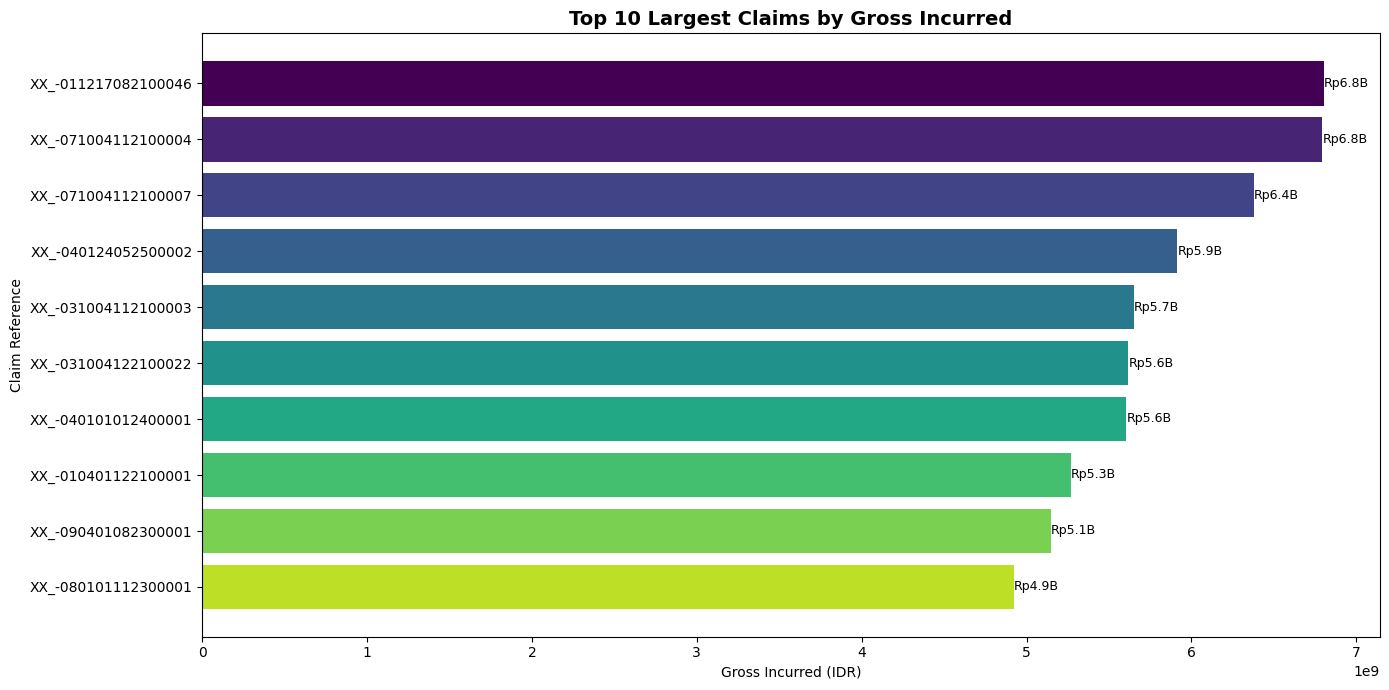

In [ ]:
# ── Top 10 Largest Claims ──

top10_claims = df_claim_merged.nlargest(10, 'GROSS_INCURRED')[
    ['CLM_REF', 'COB', 'BRANCH_', 'CHANNEL_', 'DT_CLM', 'GROSS_INCURRED', 'NET_INCURRED']
].reset_index(drop=True)

print("=== TOP 10 LARGEST CLAIMS ===")
display(top10_claims)

# Visualisasi Top 10
fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    top10_claims['CLM_REF'],
    top10_claims['GROSS_INCURRED'],
    color=plt.cm.viridis([i/10 for i in range(10)])
)

ax.set_title('Top 10 Largest Claims by Gross Incurred', fontsize=14, fontweight='bold')
ax.set_xlabel('Gross Incurred (IDR)')
ax.set_ylabel('Claim Reference')
ax.invert_yaxis()

# Tambah label nilai di tiap bar
for bar, val in zip(bars, top10_claims['GROSS_INCURRED']):
    ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
            f'Rp{val/1e9:.1f}B',
            va='center', ha='left', fontsize=9)

plt.tight_layout()
plt.show()

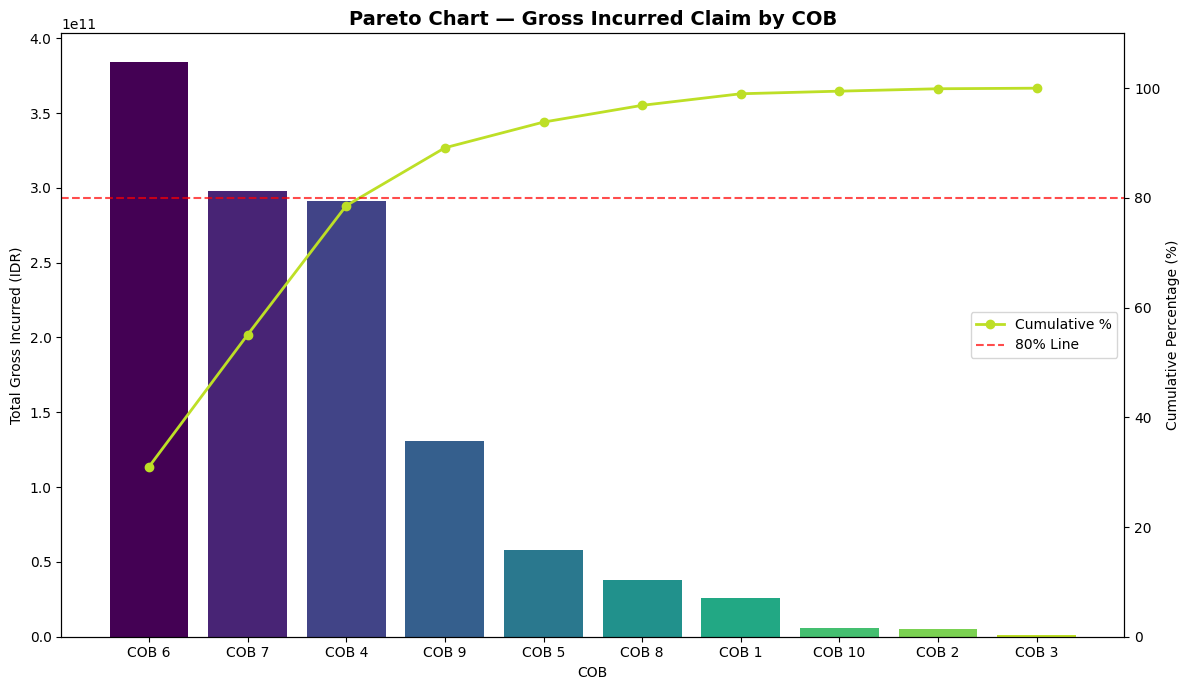

In [ ]:
# ── Pareto Chart — Claim by COB ──

pareto_data = cob_claim_analysis.sort_values(
    'Total_Gross_Incurred', ascending=False
).reset_index(drop=True)

pareto_data['Cumulative_Pct'] = (
    pareto_data['Total_Gross_Incurred'].cumsum() /
    pareto_data['Total_Gross_Incurred'].sum() * 100
)

fig, ax1 = plt.subplots(figsize=(12, 7))

# Bar chart
bars = ax1.bar(
    pareto_data['COB'],
    pareto_data['Total_Gross_Incurred'],
    color=plt.cm.viridis([i/len(pareto_data) for i in range(len(pareto_data))])
)
ax1.set_title('Pareto Chart — Gross Incurred Claim by COB',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('COB')
ax1.set_ylabel('Total Gross Incurred (IDR)')

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(
    pareto_data['COB'],
    pareto_data['Cumulative_Pct'],
    color=plt.cm.viridis(0.9),
    marker='o', linewidth=2, label='Cumulative %'
)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% Line')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

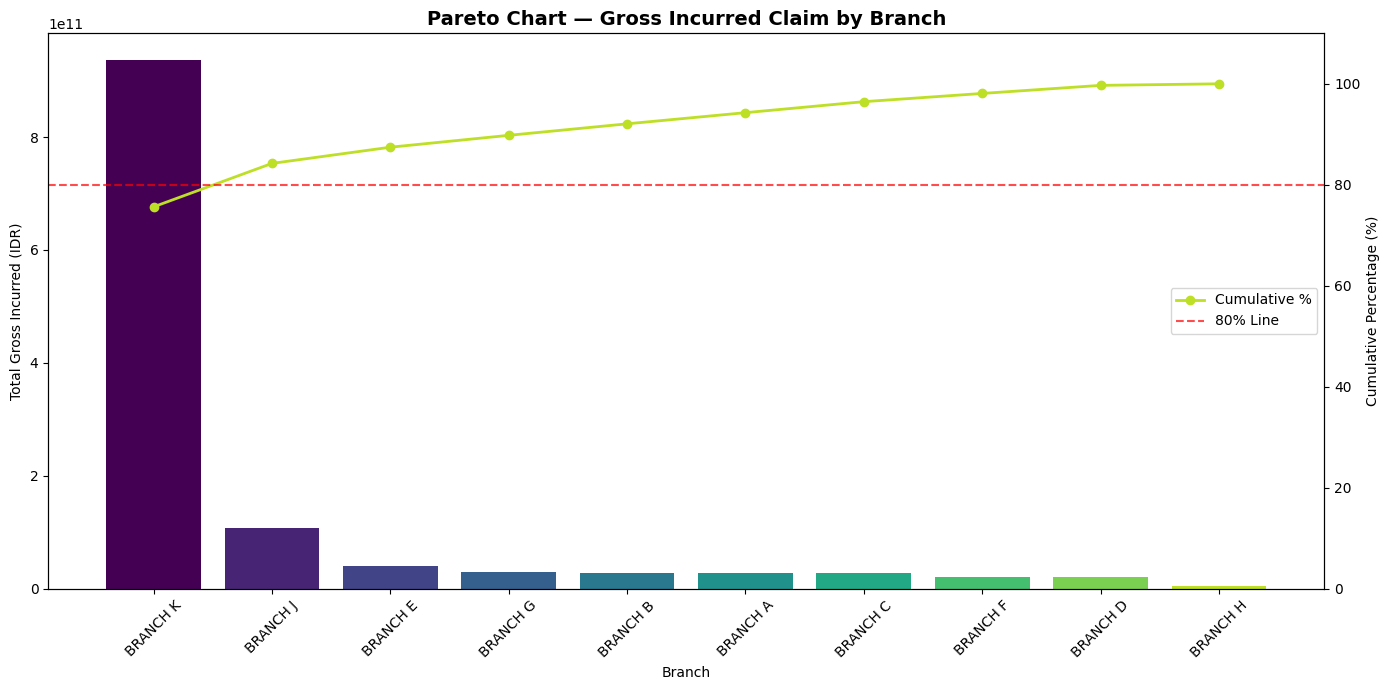

In [ ]:
# ── Pareto Chart — Claim by Branch ──

pareto_branch = branch_claim_analysis.sort_values(
    'Total_Gross_Incurred', ascending=False
).reset_index(drop=True)

pareto_branch['Cumulative_Pct'] = (
    pareto_branch['Total_Gross_Incurred'].cumsum() /
    pareto_branch['Total_Gross_Incurred'].sum() * 100
)

fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(
    pareto_branch['BRANCH_'],
    pareto_branch['Total_Gross_Incurred'],
    color=plt.cm.viridis([i/len(pareto_branch) for i in range(len(pareto_branch))])
)
ax1.set_title('Pareto Chart — Gross Incurred Claim by Branch',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Branch')
ax1.set_ylabel('Total Gross Incurred (IDR)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    pareto_branch['BRANCH_'],
    pareto_branch['Cumulative_Pct'],
    color=plt.cm.viridis(0.9),
    marker='o', linewidth=2, label='Cumulative %'
)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% Line')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

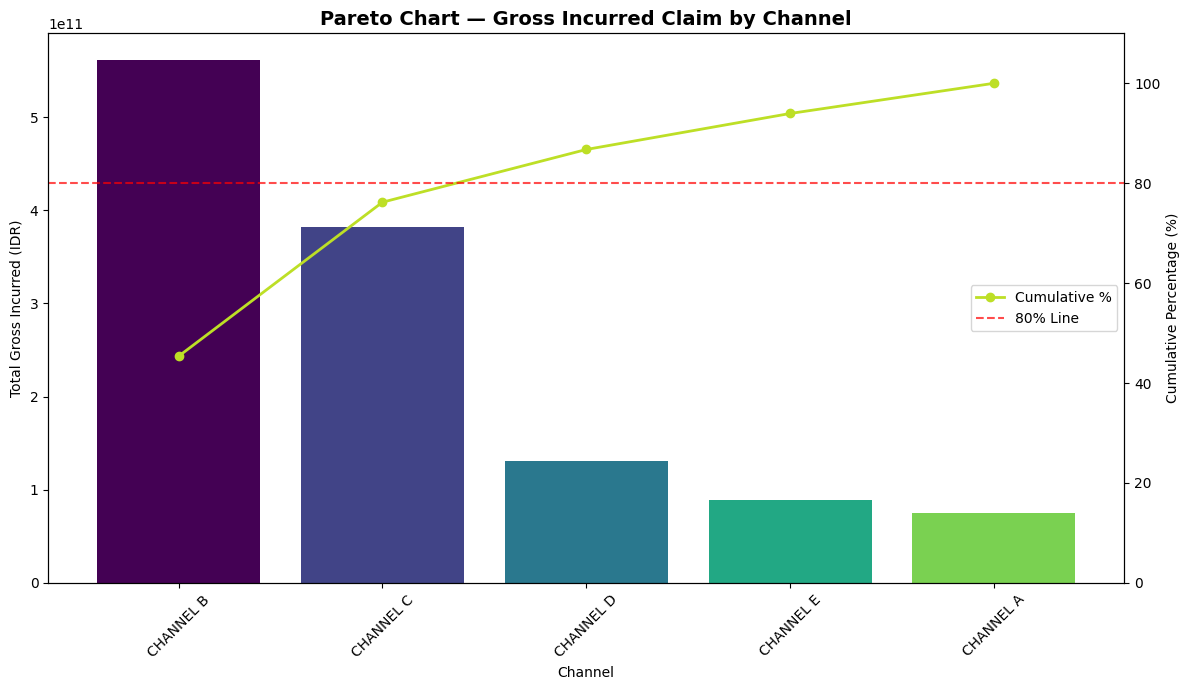

In [ ]:
# ── Pareto Chart — Claim by Channel ──

pareto_channel = channel_claim_analysis.sort_values(
    'Total_Gross_Incurred', ascending=False
).reset_index(drop=True)

pareto_channel['Cumulative_Pct'] = (
    pareto_channel['Total_Gross_Incurred'].cumsum() /
    pareto_channel['Total_Gross_Incurred'].sum() * 100
)

fig, ax1 = plt.subplots(figsize=(12, 7))

bars = ax1.bar(
    pareto_channel['CHANNEL_'],
    pareto_channel['Total_Gross_Incurred'],
    color=plt.cm.viridis([i/len(pareto_channel) for i in range(len(pareto_channel))])
)
ax1.set_title('Pareto Chart — Gross Incurred Claim by Channel',
              fontsize=14, fontweight='bold')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Total Gross Incurred (IDR)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    pareto_channel['CHANNEL_'],
    pareto_channel['Cumulative_Pct'],
    color=plt.cm.viridis(0.9),
    marker='o', linewidth=2, label='Cumulative %'
)
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='80% Line')
ax2.set_ylabel('Cumulative Percentage (%)')
ax2.set_ylim(0, 110)
ax2.legend(loc='center right')

plt.tight_layout()
plt.show()

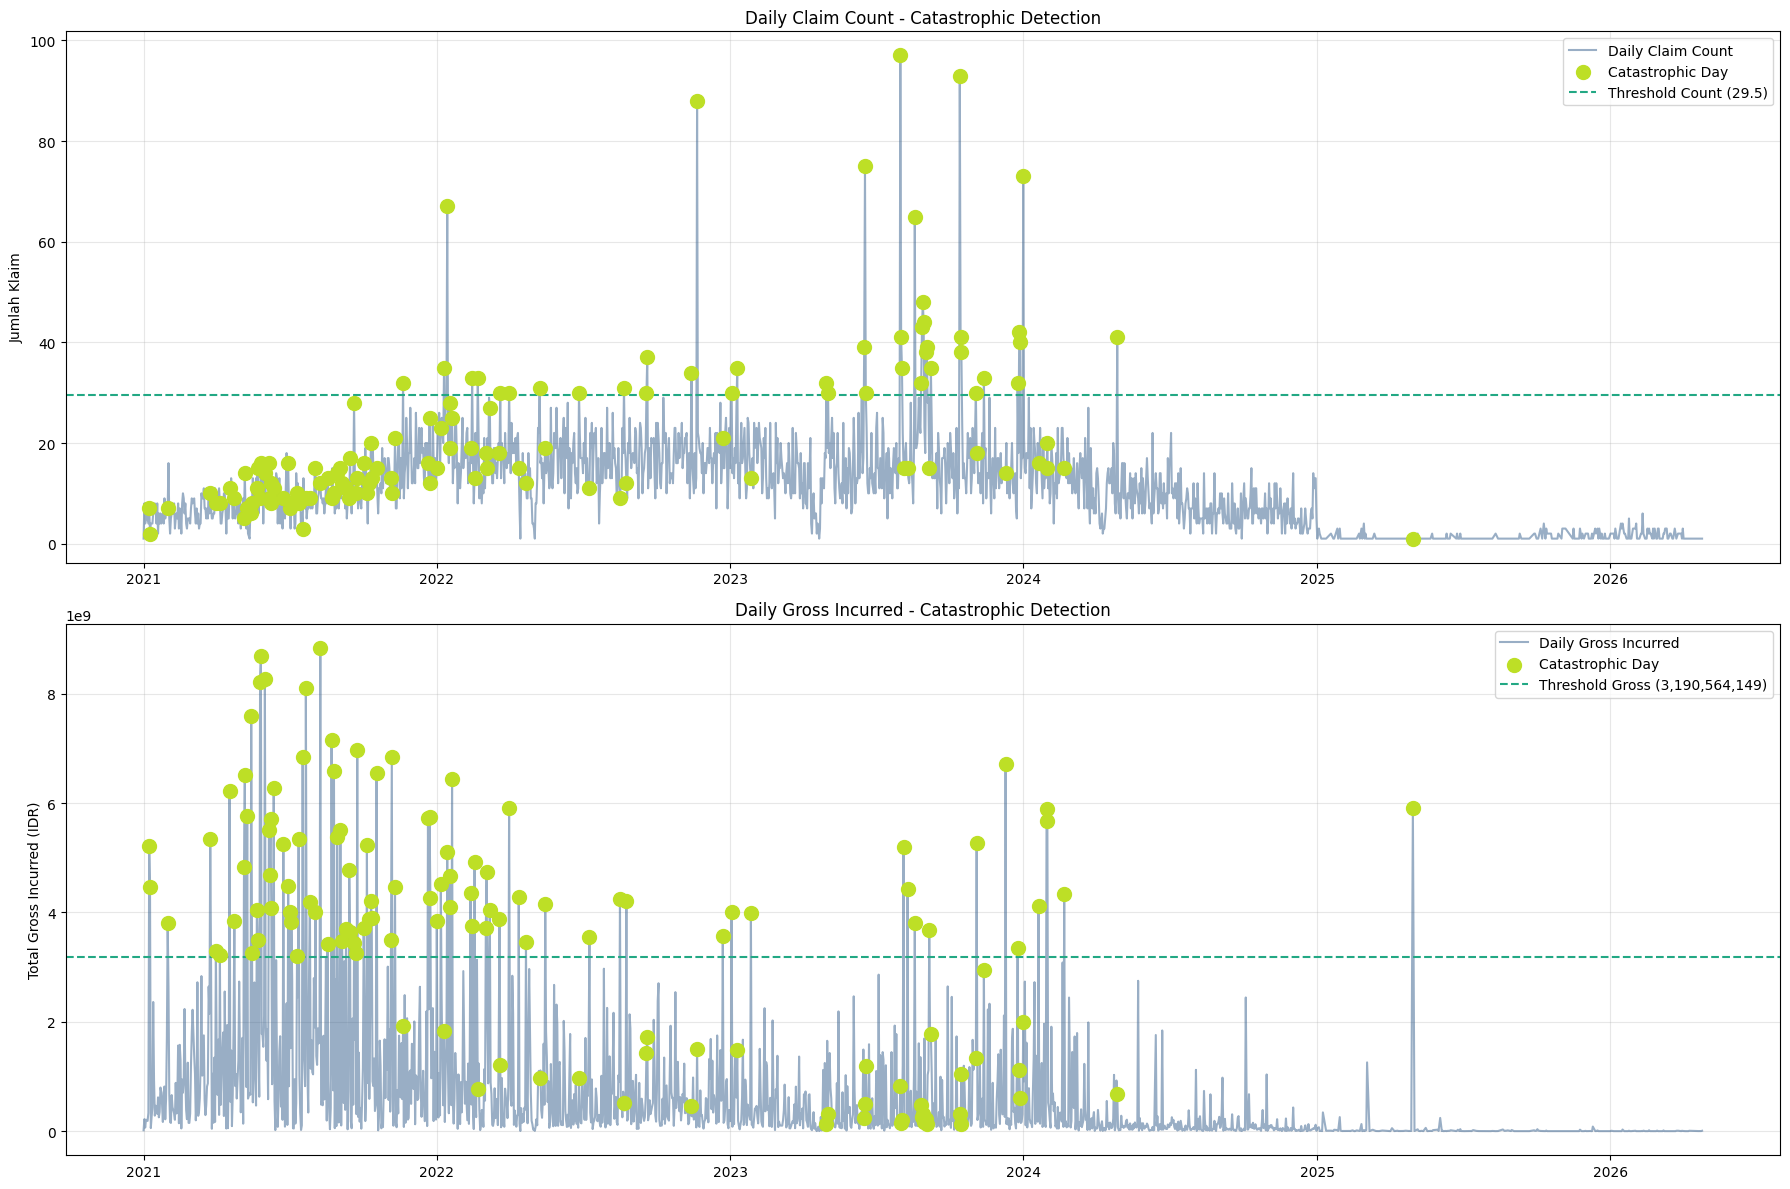

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(18, 12))

# Ambil warna dari viridis untuk konsistensi
viridis = plt.cm.viridis

# Grafik 1 - berdasarkan count
axes[0].plot(daily_claim_count['DT_CLM'],
             daily_claim_count['Daily_Claim_Count'],
             color=viridis(0.3), alpha=0.5, label='Daily Claim Count')
axes[0].scatter(catastrophic_days['DT_CLM'],
                catastrophic_days['Daily_Claim_Count'],
                color=viridis(0.9), zorder=5, label='Catastrophic Day', s=100)
axes[0].axhline(y=cat_threshold_count, color=viridis(0.6),
                linestyle='--', label=f'Threshold Count ({cat_threshold_count:.1f})')
axes[0].set_title('Daily Claim Count - Catastrophic Detection')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Grafik 2 - berdasarkan nilai gross
axes[1].plot(daily_claim_count['DT_CLM'],
             daily_claim_count['Daily_Gross'],
             color=viridis(0.3), alpha=0.5, label='Daily Gross Incurred')
axes[1].scatter(catastrophic_days['DT_CLM'],
                catastrophic_days['Daily_Gross'],
                color=viridis(0.9), zorder=5, label='Catastrophic Day', s=100)
axes[1].axhline(y=cat_threshold_gross, color=viridis(0.6),
                linestyle='--', label=f'Threshold Gross ({cat_threshold_gross:,.0f})')
axes[1].set_title('Daily Gross Incurred - Catastrophic Detection')
axes[1].set_ylabel('Total Gross Incurred (IDR)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Grafik 1

Grafik ini menunjukkan seberapa sering klaim terjadi setiap harinya. Threshold yang digunakan adalah 29.5 klaim per hari, yang dihitung dari rata-rata harian ditambah 2 kali standar deviasi. Sebuah hari dikategorikan sebagai catastrophic apabila jumlah klaim yang masuk dalam satu hari melebihi threshold tersebut. Dari grafik ini terlihat bahwa pada periode 2021 awal, frekuensi klaim masih rendah dan hampir tidak ada hari yang melewati threshold. Memasuki 2022, frekuensi klaim mulai meningkat dan mulai muncul hari-hari catastrophic. Puncaknya terjadi pada 2023-2024 dimana frekuensi klaim sangat tinggi bahkan ada hari yang mencapai hampir 100 klaim dalam sehari. Hal ini mengindikasikan bahwa pada periode tersebut AXA menghadapi tekanan operasional yang sangat tinggi karena harus memproses klaim dalam jumlah besar secara bersamaan.


Grafik 2

Grafik ini menunjukkan seberapa besar total nilai klaim yang harus ditanggung AXA setiap harinya. Threshold yang digunakan adalah Rp3,19 miliar per hari, yang juga dihitung dari rata-rata nilai harian ditambah 2 kali standar deviasi. Sebuah hari dikategorikan sebagai catastrophic apabila total nilai gross incurred dalam satu hari melebihi threshold tersebut. Dari grafik ini terlihat bahwa justru pada periode 2021 awal, hampir semua hari berada di atas threshold meskipun jumlah klaimnya sedikit. Artinya pada periode ini klaim yang masuk jumlahnya tidak banyak namun nilai per klaimnya sangat besar. Memasuki 2023-2024, meskipun frekuensi klaim tinggi, nilai gross incurred per hari justru cenderung lebih terkendali dibandingkan periode 2021. Hal ini mengindikasikan bahwa meskipun klaim makin sering terjadi, nilai per klaimnya makin kecil.
